# 11. Feedback models

## Numerical experiments - Week 38/2025

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

The collection of models can be further expanded by taking into account mechanisms of simultaneous two-sided influence by the inducer and the inhibitor. First, this can be used to correct the flaw in the assumption of an inducer-controlled inhibitor permeability. If the inducer causes a change e.g. in the cell wall porosity or in adsorbance, then this would affect its own permeation with an equivalent factor. Second, feedback loops between the two actors can be explored, resulting in models with mutual inhibitor/inducer effects, combining:
- inducer-dependent permeability (A);
- inducer-dependent inhibitor threshold (B);
- inhibitor-dependent induction strength (C);
- inhibitor-dependent permeability (D);
- inhibitor-dependent induction threshold (E);

The total number of combinations of these 5 factors is 32. Each of these compound interactions can apply to a single-factor (inducer- or inhibitor-defined) germination ($14+12$ possibilities) or a two-factor germination (32 possibilities), resulting in a total of 58 models. 9 of these have a closed analytical form (no feedback) and have already been explored.

## Prerequisite libraries

In [1]:
using PyPlot
using DifferentialEquations
using Statistics
using Distributions
using QuasiMonteCarlo
using JLD2
using Revise

# include("../src/conversions.jl")
# include("../src/diffusion.jl")
# include("../src/setup.jl")
# include("../src/plotting.jl")
# include("../src/analysis.jl")
# include("../src/datautils.jl")
# include("../src/germstats.jl")

Revise.includet("../src/conversions.jl")
Revise.includet("../src/diffusion.jl")
Revise.includet("../src/setup.jl")
Revise.includet("../src/plotting.jl")
Revise.includet("../src/analysis.jl")
Revise.includet("../src/datautils.jl")
Revise.includet("../src/germstats.jl")

using .Conversions
using .Diffusion
using .Setup
using .Plotting
using .Analysis
using .DataUtils
using .GermStats

## 1. Inducer-dependent permeability - revision

### 1.1. Mathematical formulation and integration

The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where the signal strength $s$ modulates the inhibitor permeation through the cell wall. This happens via a linear shift from a base permeability value, since it is assumed that inhibitor molecules can still escape the cell wall in the complete absence of induction.

The outside concentration changes like

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where $V_{\textrm{free}}=V_{\textrm{des}}-V_s$ is the volume unoccupied by a spore in the equally designated space per spore.

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Where $V_{\textrm{ps}}$ denotes the volume of the polysaccharide layer (inner cell wall). The permeability is modulated via the cell wall structure, so the scaling factor $s$ is used here as well. Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_0^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

As a reminder,

$$
\begin{equation}
    s{(c_{\textrm{in}}^{\textrm{C}})}=s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}},
\end{equation}
$$

where $s_{\textrm{max}}$ scales the concentration function to its appropriate magnitude of effect on the permeability. Therefore,

$$
\begin{equation}
    1+s{(c_{\textrm{in}}^{\textrm{C}})}=1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}=\frac{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}})}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}.
\end{equation}
$$

Thus, the following system of coupled ODEs needs to be solved:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{V_s(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{\left(1/\rho_s-V_s\right)(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{C}}A}{V_{\textrm{ps}}(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Factoring out $g(c_{\textrm{in}}^{\textrm{C}})=\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}A$,

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

The integration of these ODEs is demonstrated below. As a check, the number of inhibitor molecules is tracked by referring the concentrations to the respective volumes.

  0.950535 seconds (3.22 M allocations: 220.456 MiB, 4.23% gc time, 99.81% compilation time: <1% of which was recompilation)
Variance of inhibitor molecule count: 3.850572511602757e-29


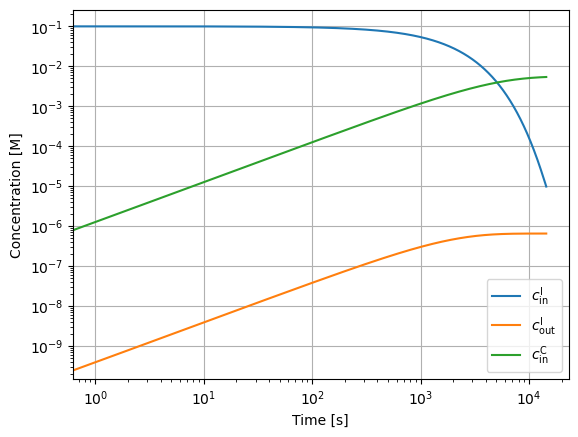

In [2]:
matplotlib.pyplot.close()

R = 2.5
A, Vₛ = compute_spore_area_and_volume_from_dia(2R)
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
V_out = 1/ρₛ - Vₛ
d_hp = 0.01
d_ps = 0.2
V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
c₀_I = 0.1 # M

# ODE function
function ode!(du, u, p, t)
    cinI, coutI, cinC = u

    # g = (p.K_cs + cinC * (1 + p.s_max)) * p.A / (p.K_cs + cinC)
    g = (1 + p.s_max * cinC / (p.K_cs + cinC)) * p.A
    rateI = g * p.Pₛ_I
    rateC = g * p.Pₛ_C

    du[1] = -(rateI / p.Vₛ) * (cinI - coutI)
    du[2] = (rateI / p.V_out) * (cinI - coutI)
    du[3] = -(rateC / p.V_ps) * (cinC - c_ex_C)
end

# Initial condition
u0 = [c₀_I, 0.0, 0.0] # [cinI, coutI, cinC]
p = (A=A, Vₛ=Vₛ, V_out=V_out, V_ps=V_ps, Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
tspan = (0.0, 14400.0)

# Integration
save_times = 0:1:14400
@time begin
    prob = ODEProblem(ode!, u0, tspan, p)
    sol = solve(prob, Tsit5(); saveat=save_times)
end
# sol = solve(prob, Rodas5())

sol_mat = reduce(hcat, sol.u)

# Molecules check
Nin = Vₛ .* sol_mat[1, :]
Nout = V_out .* sol_mat[2, :]
Ntot = Nin .+ Nout
println("Variance of inhibitor molecule count: ", var(Ntot))

# Plot concentration courses
fig, ax = subplots()
ax.loglog(sol.t, sol_mat[1, :], label=L"c_{\text{in}}^\text{I}")
ax.loglog(sol.t, sol_mat[2, :], label=L"c_{\text{out}}^\text{I}")
ax.loglog(sol.t, sol_mat[3, :], label=L"c_{\text{in}}^\text{C}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Concentration [M]")
ax.grid(true)
ax.legend()
gcf()

### 1.2. Estimation of the germination probability

Due to the non-linearity in the ODEs, there is no closed-form analytical solution and the estimation of a germination probability becomes difficult. Some simplifications can be made if it is found that the ODE mapping is approximately linear when the spore radius $R$ and the initial inhibitor concentration $c_0^\textrm{I}$ vary randomly.

A straightforward test for this involves Monte Carlo sampling of the two varying parameters under observation of the output linearity.

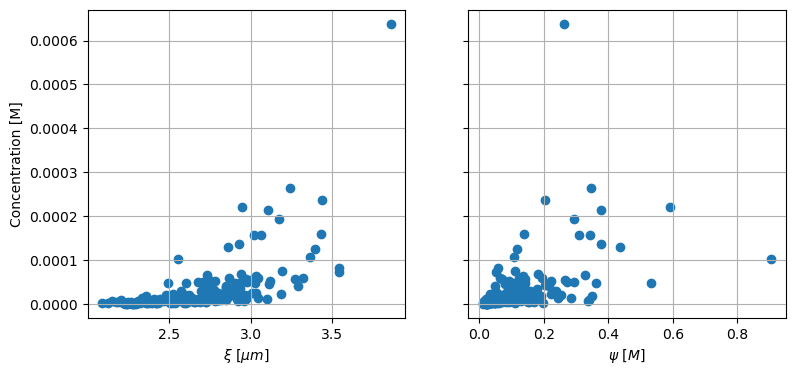

In [4]:
matplotlib.pyplot.close()

function c_in_inducer_dependent_permeability(t, ρₛ, R, d_hp, d_ps, c₀_I, c₀_C, Pₛ_I, Pₛ_C, s_max, K_cs)
    """
    Compute internal inhibitor concentration.
    inputs:
        t - time for evaluation in seconds
        ρₛ - spore density in spores/mL
        R - spore density in μm
        d_hp - hydrophobin layer thickness in μm
        d_ps - polysaccharide layer thickness in μm
        c₀_I - initial internal inhibitor concentration in M
        c₀_I - initial external inducer concentration in M
        Pₛ_I - inhibitor permeation constant in μm/s
        Pₛ_C - inducer permeation constant in μm/s
        s_max - maximum inductive signal strength
        K_cs - half-saturation constant for the carbon source in M
    """

    A, Vₛ = compute_spore_area_and_volume_from_dia(2*R)
    ρₛ = inverse_mL_to_cubic_um(ρₛ) # spores/mL
    V_out = 1/ρₛ - Vₛ
    V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)

    # ODE function
    function ode!(du, u, p, t)
        cinI, coutI, cinC = u

        # g = (K_cs + cinC * (1 + s_max)) * A / (K_cs + cinC)
        g = (1 + s_max * cinC / (K_cs + cinC)) * A
        rateI = g * Pₛ_I
        rateC = g * Pₛ_C

        du[1] = -(rateI / Vₛ) * (cinI - coutI)
        du[2] = (rateI / V_out) * (cinI - coutI)
        du[3] = -(rateC / V_ps) * (cinC - c_ex_C)
    end

    u0 = [c₀_I, 0.0, 0.0]
    tspan = (0.0, t)

    prob = ODEProblem(ode!, u0, tspan)
    sol = solve(prob, Tsit5())

    return sol.u[end][1]
end

# Random samples
n_samples = 200

μ_ξ = 2.65
σ_ξ = 0.3
μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
samples_ξ = rand(dist_ξ, n_samples)

μ_ψ = 0.1
σ_ψ = 0.1
μ_ψ_log = log(μ_ψ^2 / sqrt(σ_ψ^2 + μ_ψ^2))
σ_ψ_log = sqrt(log(σ_ψ^2 / μ_ψ^2 + 1))
dist_ψ = LogNormal(μ_ψ_log, σ_ψ_log)
samples_ψ = rand(dist_ψ, n_samples)

t_max = 14400
samples_c_in = zeros(n_samples)
for n in 1:n_samples
    samples_c_in[n] = c_in_inducer_dependent_permeability(t_max, inverse_mL_to_cubic_um(1e5), samples_ξ[n], d_hp, d_ps, samples_ψ[n], c_ex_C, Pₛ_I, Pₛ_C, s_max, K_cs)
end

# Plot samples
fig, ax = subplots(1, 2, figsize=(9, 4), sharey=true)
ax[1].grid(true)
ax[2].grid(true)
ax[1].scatter(samples_ξ, samples_c_in)
ax[2].scatter(samples_ψ, samples_c_in)
ax[1].set_xlabel(L"\xi \ [\mu m]")
ax[1].set_ylabel("Concentration [M]")
ax[2].set_xlabel(L"\psi \ [M]")
# ax.grid(true)
gcf()

The scatter plots demonstrate clearly that the ODE mapping is not linear both $\psi$ and $\xi$. Therefore, a linear approximation is not feasible and Monte Carlo sampling appears the best way to integrate the germination probabilities. The case observed below is an inhibitor-dependent germination with an inducer-dependent cell wall permeability. Hence, $\gamma$ is added as a random parameter. It is investigated at what sample size the solution converges to a stable value by measuring the variance of 50 runs per sample size.

The sampling is performed using shuffled Sobol sequences.

In [6]:
# Fixed parameters
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
d_hp = 0.01 # μm
d_ps = 0.2 # μm

t_query = 14400
n_sample_range = 2 .^ (3:15)
n_runs = 50

μ_ξ = 2.65
σ_ξ = 0.3
μ_ψ = 0.1
σ_ψ = 0.1
μ_γ = 1e-2
σ_γ = 1e-3

# Template problem
dummyA, dummyV = compute_spore_area_and_volume_from_dia(2*μ_ξ)
p_template = (A=dummyA, Vₛ=dummyV, V_out=1.0/ρₛ - dummyV, V_ps=0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3),
              Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
u0_template = [μ_ψ, 0.0, 0.0]
tspan = (0.0, t_query)
prob = ODEProblem(ode!, u0_template, tspan, p_template)

pct_means = zeros(length(n_sample_range))
pct_vars = zeros(length(n_sample_range))

for (i, n_samples) in enumerate(n_sample_range)

    println("Running sample size ", n_samples)
    
    pcts = zeros(n_runs)

    for j in 1:n_runs

        # Random samples
        sobol_pts = QuasiMonteCarlo.sample(n_samples, 3, SobolSample(R = OwenScramble(base = 2, pad = 2+i)))
        
        μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
        σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
        dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
        samples_ξ = max.(quantile(dist_ξ, sobol_pts[1,:]), 1e-12)

        μ_ψ_log = log(μ_ψ^2 / sqrt(σ_ψ^2 + μ_ψ^2))
        σ_ψ_log = sqrt(log(σ_ψ^2 / μ_ψ^2 + 1))
        dist_ψ = LogNormal(μ_ψ_log, σ_ψ_log)
        samples_ψ = max.(quantile(dist_ψ, sobol_pts[2,:]), 1e-12)

        μ_γ_log = log(μ_γ^2 / sqrt(σ_γ^2 + μ_γ^2))
        σ_γ_log = sqrt(log(σ_γ^2 / μ_γ^2 + 1))
        dist_γ = LogNormal(μ_γ_log, σ_γ_log)
        samples_γ = max.(quantile(dist_γ, sobol_pts[3,:]), 1e-12)

        samples_AV = compute_spore_area_and_volume_from_dia.(2 .* samples_ξ)
        samples_A, samples_Vₛ = (map(x -> x[1], samples_AV), map(x -> x[2], samples_AV))
        samples_V_out = 1.0 / ρₛ .- samples_Vₛ
        samples_V_ps = compute_ps_layer_volume.(samples_ξ, d_hp, d_ps)

        # println(samples_A[1:5])
        # println(samples_Vₛ[1:5])
        # println(samples_V_out[1:5])
        # println(samples_V_ps[1:5])

        function prob_func(prob, i, repeat)
            r = max(samples_ξ[i], 1e-9)

            new_p = (A=samples_A[i], Vₛ=samples_Vₛ[i], V_out=samples_V_out[i], V_ps=samples_V_ps[i],
                Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)

            new_u0 = [samples_ψ[i], 0.0, 0.0]
            remake(prob; u0 = new_u0, p = new_p)
        end

        # Run ODE ensembles
        ep = EnsembleProblem(prob; prob_func=prob_func)
        sols = solve(ep, Rodas5(), EnsembleThreads(), trajectories=n_samples, saveat=[t_query])

        # Evaluate fraction germinated
        c_inI_at_t = [ sols[i](t_query)[1] for i in 1:n_samples ]
        # println("Mean internal inhibitor concentration: ", mean(c_inI_at_t))
        germinated = c_inI_at_t .< samples_γ
        pct = 100 * mean(germinated)
        # println("Percent germinated: ", pct)

        pcts[j] = pct
    end

    pct_means[i] = mean(pcts)
    pct_vars[i] = var(pcts)
end

Running sample size 8
Running sample size 16
Running sample size 32
Running sample size 64
Running sample size 128
Running sample size 256
Running sample size 512
Running sample size 1024
Running sample size 2048
Running sample size 4096
Running sample size 8192
Running sample size 16384
Running sample size 32768


[21.428571428571427, 6.377551020408164, 0.3826530612244898, 0.0, 0.02391581632653061, 0.005978954081632653, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


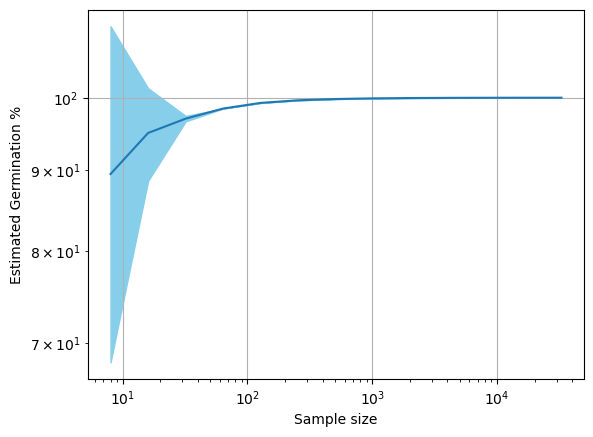

In [7]:
println(pct_vars)
fig, ax = subplots()
ax.loglog(n_sample_range, pct_means)
ax.fill_between(n_sample_range, pct_means .- pct_vars, pct_means .+ pct_vars, color="skyblue")
ax.grid()
# ax.set_ylim(0, 10)
ax.set_xlabel("Sample size")
ax.set_ylabel("Estimated Germination %")
gcf()

It is thus visible that the variance converges at about $\mathcal{O}(10^3)$ samples, while the mean stabilizes at about $\mathcal{O}(10^4)$ samples. The lower sample size can be taken as sufficiently accurate for the practical purposes.

This enables a performance test of a parameter estimation procedure with the developed model. First, a typical time evolution of the germination percentage is explored using exemplary parameter values.

In [25]:
model_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 5e-4,
    :Pₛ_cs => 1e-5,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :μ_ω => 1e-3,
    :σ_ω => 1e-4,
    :s_max => 0.5,
    :b_max => 0.5,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :k_C => 0.1
)

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inhibitor_inducer_perm", times_eval, density_test, model_params)

matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

┌ Error: Failed to revise d:\MSc Computational Science\Master Thesis\msc-thesis\src\germstats.jl
│   exception = Revise.ReviseEvalException("C:\\Users\\mihbo\\.julia\\packages\\Parameters\\MK0O4\\src\\Parameters.jl:611", ErrorException("invalid redefinition of constant GermStats.PermParams"), Any[(top-level scope at Parameters.jl:611, 1)])
└ @ Revise C:\Users\mihbo\.julia\packages\Revise\PSzoa\src\packagedef.jl:741
┌ Warning: The running code does not match the saved version for the following files:
│ 
│   d:\MSc Computational Science\Master Thesis\msc-thesis\src\germstats.jl
│ 
│ If the error was due to evaluation order, it can sometimes be resolved by calling `Revise.retry()`.
│ Use Revise.errors() to report errors again. Only the first error in each file is shown.
│ Your prompt color may be yellow until the errors are resolved.
└ @ Revise C:\Users\mihbo\.julia\packages\Revise\PSzoa\src\packagedef.jl:859


MethodError: MethodError: no method matching germ_response_feedback_perm(::typeof(ode_inducer_dependent_perm!), ::typeof(thresh_criterion_inhibitor), ::Matrix{Float64}, ::LinRange{Float64, Int64}, ::Vector{Vector{Float64}}, ::Float64, ::Vector{Float64}, ::Float64, ::Float64, ::Vector{Union{Nothing, Float64}}, ::Float64, ::Float64, ::Vector{Float64}, ::Vector{Float64})

As a next step, the previously used parameter optimisation procedure is applied on the current model.

In [2]:
t_max = 48
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, errs, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)

# Define default parameters globally
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Define parameter bounds globally
bounds_narrow = Dict(
    :s_max => (1e-4, 1e4),
    :b_max => (1e-4, 1.0),
    :Pₛ => (1e-4, 1e-3),
    :Pₛ_cs => (1e-7, 1e-2),
    :k_C => (-6, 6),
    :k_I => (-6, 6),
    :K_I => (1e-5, 1.0),
    :K_cC => (1e-8, 0.1),
    :K_cI => (1e-8, 0.1),
    :n => (1.0, 3.0),
    :s => (1e-6, 1.0),
    :μ_γ => (1e-6, 1e-4),
    :δ_γ => (-10, -0.5),
    :μ_ω => (1e-6, 10.0),
    :δ_ω => (-10, -0.5),
    :μ_ψ => (1e-5, 1.0),	
    :δ_ψ => (-10, 0),
    :μ_π => (1e-4, 1e-3),
    :δ_π => (-10, 0),
    :μ_α => (1e-4, 1.0),
    :δ_α => (-10, 0)
)

bounds_broad = Dict(
    :s_max => (1e-4, 1e4),
    :b_max => (1e-4, 1.0),
    :Pₛ => (1e-5, 1e-2),
    :Pₛ_cs => (1e-8, 1e-2),
    :k_C => (-6, 6),
    :k_I => (-6, 6),
    :K_I => (1e-5, 1.0),
    :K_cC => (1e-8, 10.0),
    :K_cI => (1e-8, 10.0),
    :n => (1.0, 3.0),
    :s => (1e-6, 1.0),
    :μ_γ => (1e-8, 1e-1),
    :δ_γ => (-10, -0.5),
    :μ_ω => (1e-6, 10.0),
    :δ_ω => (-10, -0.5),
    :μ_ψ => (1e-5, 1.0),	
    :δ_ψ => (-10, 0),
    :μ_π => (1e-4, 1e-3),
    :δ_π => (-10, 0),
    :μ_α => (1e-4, 1.0),
    :δ_α => (-10, 0)
)

bounds_narrowest = Dict(
    :s_max => (1e-2, 1.0),
    :b_max => (1e-2, 1.0),
    :Pₛ => (1e-4, 1e-3),
    :Pₛ_cs => (1e-6, 1e-4),
    :k_C => (-2, 2),
    :k_I => (-2, 2),
    :K_I => (1e-5, 1.0),
    :K_cC => (1e-3, 0.1),
    :K_cI => (1e-3, 0.1),
    :n => (1.0, 3.0),
    :s => (1e-6, 1.0),
    :μ_γ => (1e-6, 1e-4),
    :δ_γ => (-10, -0.5),
    :μ_ω => (1e-6, 1e-4),
    :δ_ω => (-10, -0.5),
    :μ_ψ => (1e-3, 1.0),	
    :δ_ψ => (-5, 0),
    :μ_π => (1e-4, 1e-3),
    :δ_π => (-10, 0),
    :μ_α => (1e-4, 1.0),
    :δ_α => (-10, 0)
)

example_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 5e-4,
    :Pₛ_cs => 1e-5,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :μ_ω => 1e-3,
    :σ_ω => 1e-4,
    :s_max => 0.5,
    :b_max => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

Dict{Symbol, Real} with 22 entries:
  :σ_ψ   => 0.01
  :c₀_cs => 0.01
  :μ_κ   => 0.2
  :σ_ξ   => 0.3
  :μ_ξ   => 2.65
  :d_hp  => 0.01
  :σ_κ   => 0.05
  :k_I   => 1.0
  :K_cI  => 0.01
  :K_cC  => 0.01
  :Pₛ_cs => 1.0e-5
  :K_I   => 0.01
  :n     => 2
  :μ_ψ   => 0.5
  :μ_ω   => 0.001
  :Pₛ    => 0.0005
  :σ_ω   => 0.0001
  :σ_γ   => 0.0001
  :b_max => 0.95
  ⋮      => ⋮

In [ ]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

0.248467255118905


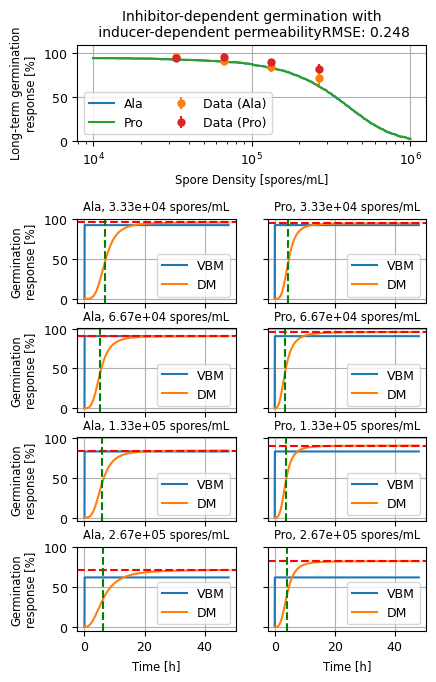

In [10]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

### 1.3. Model naming convention

The feedback model identifier strings follow a specific logic. As an example, in `feedback_inhibitor_inhibitor_inducer_perm`, the first substring (`feedback`) indicates that it is a feedback model. The second substring (`inhibitor`) indicates which threshold criterion is being observed: one with regard to the inhibitor, to the inducer, or both (as indicated by the `combined` tag). Finally, the remaining substrings indicate which actors affect corresponding components from the (opposite) pathway. In this case, `inhibitor_inducer_perm` signals that both the inhibitor and the inducer affect the permeability of the cell wall.

## 2. Remaining feedback models

The main difference among the remaining feedback models lies in the formulation of the ODEs. The following sections outline the governing equations and attempt a systematic completion of all model variants.

### 2.1. Single-interaction models

#### 2.1.1. Inducer-dependent cell wall permeability (A)

The ODEs for this scenario were outlined in Section 1. Two possible variants exist:
- 2-factor germination;
- inhibitor-dependent germination (already explored).

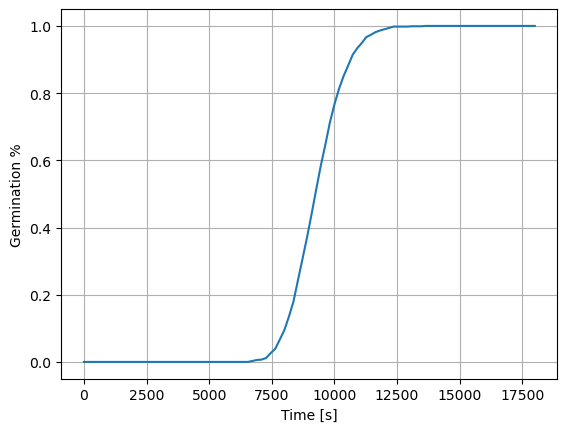

In [15]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inducer_perm", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [6]:
max_steps = 100
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
12.06 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
22.99 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5107.093023986
34.69 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5107.093023986
45.43 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5107.093023986
56.84 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5107.093023986
67.60 secs, 12 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5107.093023986
79.15 secs, 14 evals, 7 steps, improv/step: 1

Dict{Any, Any} with 10 entries:
  :σ_γ   => [3.22104e-5]
  :σ_ω   => [0.00388949, 0.0129457]
  :σ_ψ   => [0.65651]
  :μ_ω   => [0.00675096, 4.39333]
  :K_cC  => [0.0422527, 0.0483041]
  :μ_ψ   => [0.684621]
  :s_max => [9359.56, 7144.27]
  :Pₛ    => [0.000775785]
  :Pₛ_cs => [0.00074288, 0.00351925]
  :μ_γ   => [5.57291e-5]

0.6277229332595818


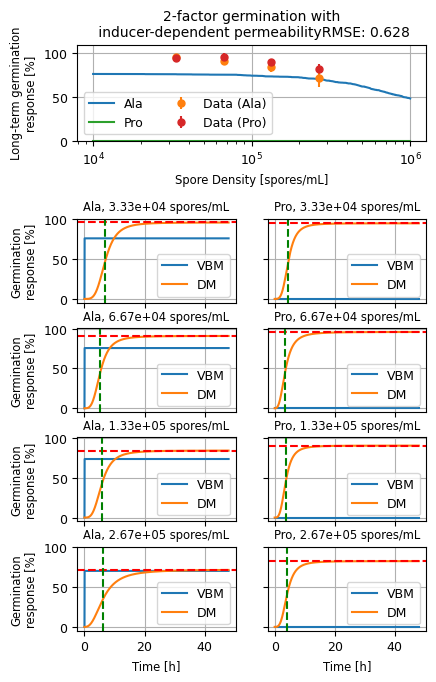

In [7]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.1.2. Inhibitor-dependent cell wall permeability (D)

It has been observed that 1-octen-3-ol increases the cell membrane permeability. If this also affects the overall permeability through the spore envelope, then a similar ODE system can be developed as before:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{I}})=\left(1-b_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}}\right)A=\frac{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}(1-b_{\textrm{max}})}{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}}A,
$$

a Michaelis-Menten modulation of the permeability through the inhibitor concentration, where $0\le b_{\textrm{max}}\le 1$.

This scenario may apply to two types of germination trigger:
- 2-factor germination;
- inducer-dependent germination.

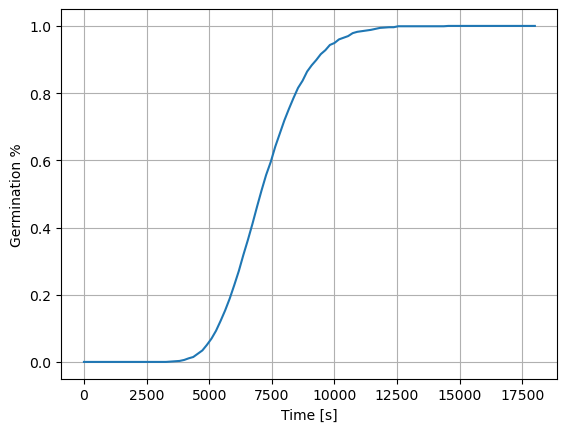

In [19]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inducer_inhibitor_perm", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [5]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inducer-dependent germination with inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
10.75 secs, 2 evals, 1 steps, fitness=882.691486312
21.81 secs, 4 evals, 2 steps, fitness=882.691486312
32.67 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 1.0000), fitness=882.691486312
43.99 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 1.0000), fitness=882.691486312
55.47 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=882.691486312
60.58 secs, 11 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=882.691486312
71.82 secs, 13 evals, 7 steps, improv/step: 0.714 (last = 1.0000), fitness=882.691486312
77.31 secs, 14 evals, 8

Dict{Any, Any} with 8 entries:
  :b_max => [0.996773]
  :σ_ψ   => [0.107493]
  :K_cI  => [0.00291556]
  :μ_ω   => [8.64898e-5, 9.91233e-5]
  :μ_ψ   => [0.849412]
  :Pₛ    => [0.000586161]
  :σ_ω   => [5.18111e-5, 5.15933e-5]
  :Pₛ_cs => [1.86776e-6, 3.48638e-6]

0.13043164272607685


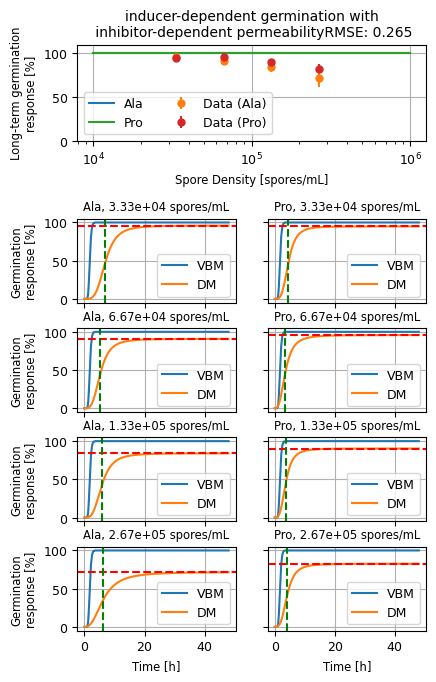

In [6]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_perm", example_params, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [15]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.08 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
21.42 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
32.28 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
43.25 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
53.57 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
58.76 secs, 11 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5044.894603166
69.14 secs, 13 evals, 7 steps, improv/step:

Dict{Any, Any} with 10 entries:
  :σ_γ   => [8.1972e-9]
  :b_max => [0.999365]
  :σ_ψ   => [0.0819626]
  :K_cI  => [0.0950782]
  :μ_ω   => [0.00643158, 4.48398]
  :μ_ψ   => [0.631807]
  :μ_γ   => [2.51508e-5]
  :Pₛ    => [0.000784558]
  :σ_ω   => [0.00390035, 0.00916428]
  :Pₛ_cs => [0.0092539, 0.00310951]

0.6070762160667234


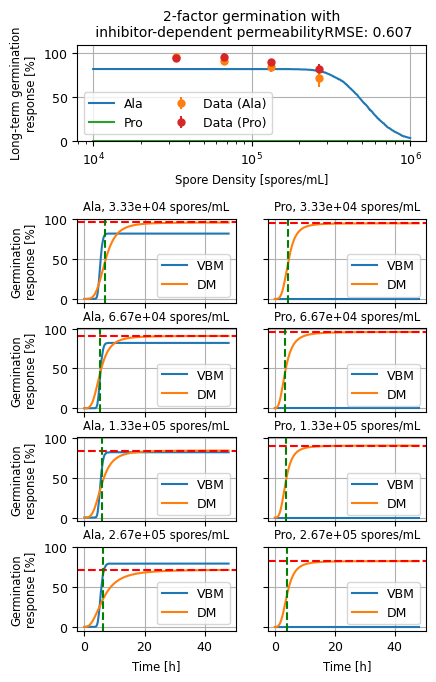

In [16]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

### 2.2. Double-interaction models

#### 2.2.1. Inducer-dependent cell wall permeability and inhibition threshold (AB)

The ODEs for this scenario are the same as in Section 1, but the inhibition threshold is additionally shifted by an amount proportional to the time-dependent inducer concentration. The applicable triggering variants are:
- 2-factor germination;
- inhibitor-dependent germination.

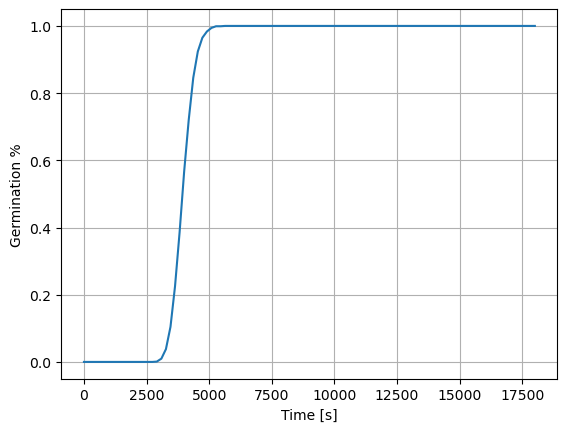

In [20]:
t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inhibitor_inducer_perm_thresh", times_eval, density_test, example_params)

matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [10]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: inhibitor-dependent germination with inducer-dependent permeability and inhibition threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.03 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=776.505290622
22.31 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=776.505290622
33.50 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=776.505290622
44.31 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=753.439045230
54.72 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=753.439045230
66.19 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=753.439045230
76.96 secs, 14 evals, 7 steps, im

Dict{Any, Any} with 9 entries:
  :σ_γ   => [3.24377e-9]
  :σ_ψ   => [0.00352834]
  :k_C   => [1.7079, 1.00664]
  :K_cC  => [0.0594427, 0.0965266]
  :μ_ψ   => [0.278267]
  :s_max => [0.682402, 0.125101]
  :Pₛ    => [0.000328928]
  :Pₛ_cs => [2.04021e-5, 7.93447e-5]
  :μ_γ   => [6.84042e-5]

0.26056945496135553


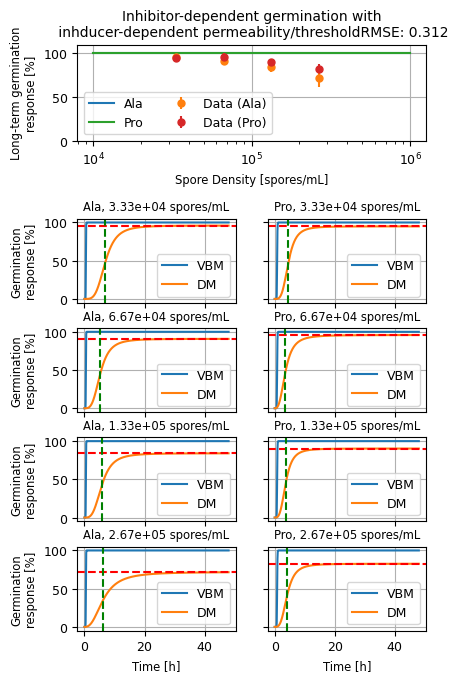

In [6]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

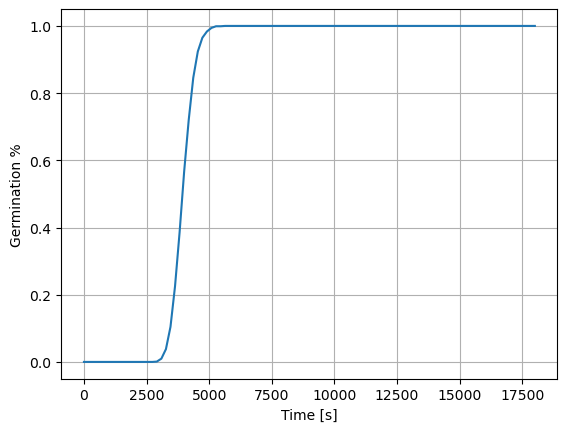

In [5]:
t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inducer_perm_thresh", times_eval, density_test, example_params)

matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [24]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inducer-dependent permeability and inhibition threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
10.13 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=2711.766087762
21.43 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=595.538988295
33.00 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 0.0000), fitness=595.538988295
49.33 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=310.308347260
59.83 secs, 10 evals, 5 steps, improv/step: 0.400 (last = 0.0000), fitness=310.308347260
71.93 secs, 12 evals, 6 steps, improv/step: 0.333 (last = 0.0000), fitness=310.308347260
83.19 secs, 14 evals, 7 steps, improv/step:

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.137727]
  :μ_ψ   => [0.637108]
  :μ_ω   => [8.34501e-5, 8.06899e-5]
  :σ_ω   => [3.79209e-6, 4.4058e-5]
  :Pₛ    => [0.000131947]
  :σ_γ   => [1.5102e-6]
  :k_C   => [1.09049, 1.67234]
  :K_cC  => [0.0564301, 0.0982695]
  :μ_γ   => [1.75231e-5]
  :s_max => [0.143606, 0.975736]
  :Pₛ_cs => [7.69027e-5, 9.53386e-5]

0.16649885894039684


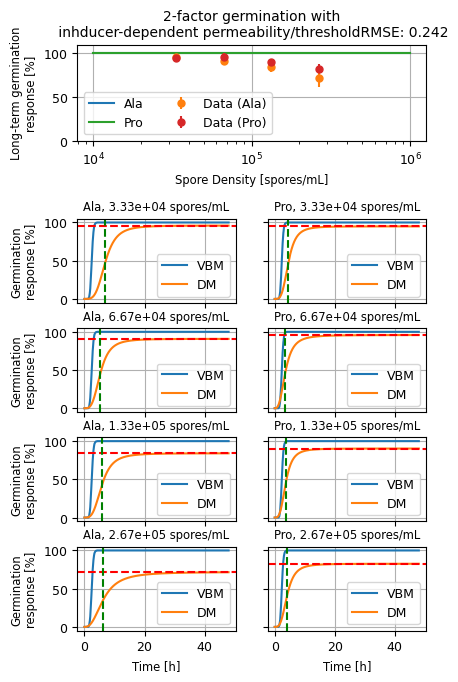

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.2.2. Inducer-dependent cell wall permeability and inhibitor-dependent induction strength (AC)

This double feedback loop combines a self-modulation of the induction strength via the cell wall permeability and via the accumulation of inhibitor. The ODEs are

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s'\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}\right)A, \quad s'=s_{\textrm{max}}\left[\frac{1}{1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}}{K_I}\right)^n}\right].
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

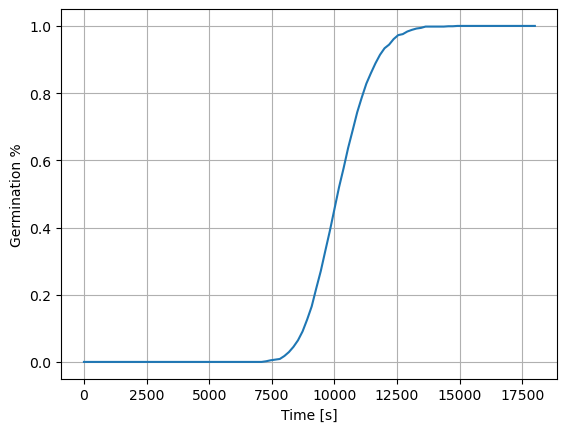

In [6]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inhibitor_inducer_perm_inhibitor_signal", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [15]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inducer-dependent permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.37 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=433.522663604
22.68 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=250.900749699
34.89 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 0.0000), fitness=250.900749699
46.45 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 1.0000), fitness=250.900749699
58.34 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=250.900749699
70.36 secs, 12 evals, 6 steps, improv/step: 0.500 (last = 0.0000), fitness=250.900749699
82.09 secs, 14 ev

Dict{Any, Any} with 10 entries:
  :σ_γ   => [4.25666e-7]
  :σ_ψ   => [0.952876]
  :K_cI  => [0.0586212]
  :n     => [2.1036, 1.88911]
  :K_cC  => [0.0685258, 0.0670261]
  :μ_ψ   => [0.952984]
  :s_max => [0.0585419, 0.991677]
  :Pₛ    => [0.000461414]
  :Pₛ_cs => [3.41009e-5, 6.24388e-5]
  :μ_γ   => [2.27211e-5]

0.10385464097513461


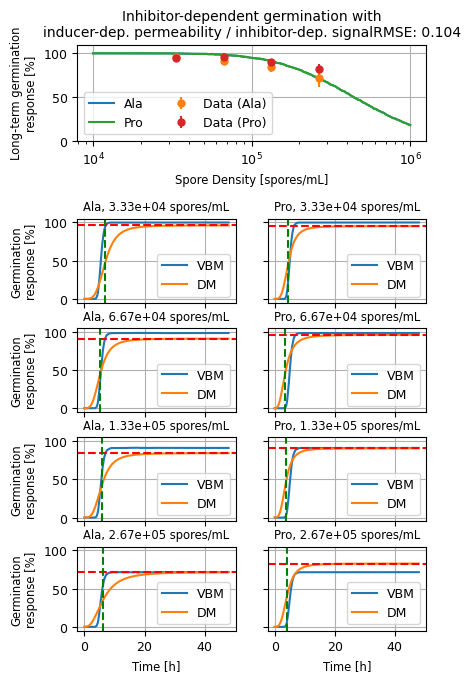

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [17]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inducer-dependent germination with inducer-dependent permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
12.02 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
24.92 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
36.47 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 0.0000), fitness=886.772924414
47.99 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=886.772924414
59.44 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=886.772924414
70.66 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=886.772924414
83.16 secs, 14 eval

Dict{Any, Any} with 10 entries:
  :σ_ψ   => [0.0105499]
  :K_cI  => [0.0447243]
  :n     => [1.48718, 1.75654]
  :μ_ω   => [5.28244e-5, 8.11154e-6]
  :K_cC  => [0.0772705, 0.00585056]
  :μ_ψ   => [0.756573]
  :s_max => [0.740396, 0.269642]
  :Pₛ    => [0.000536083]
  :Pₛ_cs => [1.13251e-5, 2.10172e-6]
  :σ_ω   => [6.32788e-9, 4.89785e-8]

0.33293635360495333


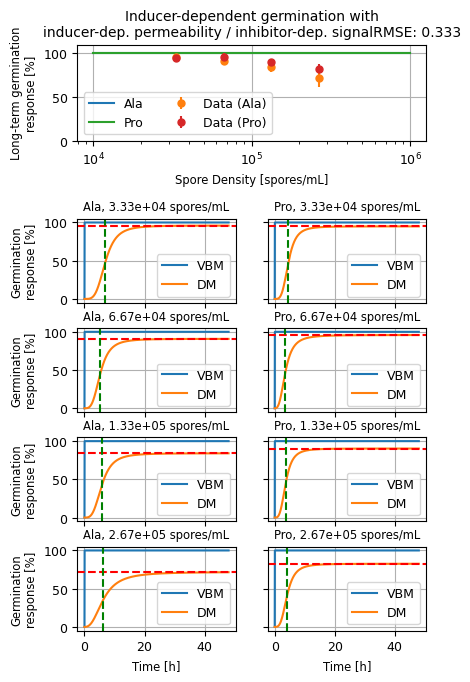

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [19]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inducer-dependent permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
12.46 secs, 2 evals, 1 steps, fitness=240.974734793
23.59 secs, 4 evals, 2 steps, fitness=240.974734793
34.98 secs, 6 evals, 3 steps, fitness=240.974734793
46.57 secs, 8 evals, 4 steps, improv/step: 0.250 (last = 1.0000), fitness=240.974734793
58.62 secs, 10 evals, 5 steps, improv/step: 0.400 (last = 1.0000), fitness=240.974734793
64.49 secs, 11 evals, 6 steps, improv/step: 0.333 (last = 0.0000), fitness=240.974734793
76.63 secs, 13 evals, 7 steps, improv/step: 0.286 (last = 0.0000), fitness=240.974734793
88.88 secs, 15 evals, 8 steps, improv/step: 0.3

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.999176]
  :n     => [1.41904, 2.27271]
  :μ_ψ   => [0.99945]
  :μ_ω   => [5.14487e-5, 1.37154e-5]
  :σ_ω   => [8.47218e-9, 1.06102e-6]
  :Pₛ    => [0.000380137]
  :σ_γ   => [2.24511e-5]
  :K_cI  => [0.0207023]
  :K_cC  => [0.0739195, 0.00100014]
  :μ_γ   => [3.70156e-5]
  :s_max => [0.89927, 0.999281]
  :Pₛ_cs => [4.44931e-5, 4.16378e-5]

0.07429659928207888


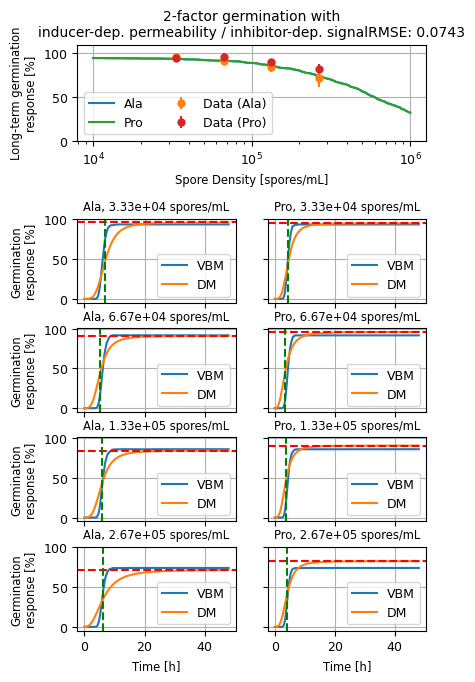

In [5]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.2.3. Inducer- and inhibitor-dependent cell wall permeability (AD)

In this scenario, the cell wall permeability is simultaneously modulated by the inducer and by the inhibitor concentration. The ODEs take the form

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$  
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}-b_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{I}}+c_{\textrm{in}}^{\textrm{I}}}\right)A.
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

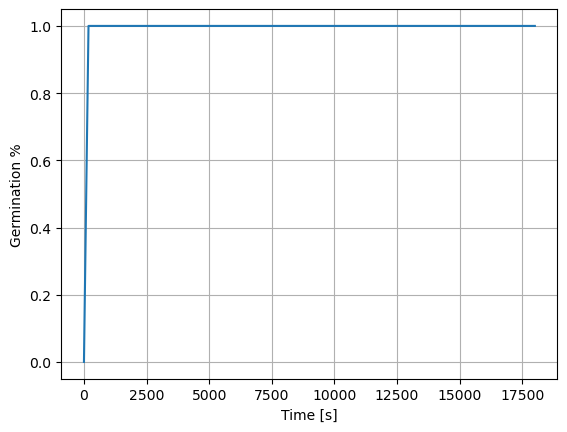

In [22]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inducer_inhibitor_inducer_perm", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [24]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inhibitor_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inhibitor_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.59 secs, 2 evals, 1 steps, fitness=878.440906075
23.36 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 1.0000), fitness=664.683421405
34.52 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 0.0000), fitness=664.683421405
45.69 secs, 8 evals, 4 steps, improv/step: 0.250 (last = 0.0000), fitness=664.683421405
56.40 secs, 10 evals, 5 steps, improv/step: 0.400 (last = 1.0000), fitness=664.683421405
67.44 secs, 12 evals, 6 steps, improv/step: 0.333 (last = 0.0000), fitness=664.683421405
79.55 secs, 14 evals, 7 steps, improv/step: 0.429 (last = 1.0

Dict{Any, Any} with 10 entries:
  :σ_γ   => [1.69087e-5]
  :b_max => [0.736351]
  :σ_ψ   => [0.0531913]
  :K_cI  => [0.00548359]
  :K_cC  => [0.0986981, 0.0983204]
  :μ_ψ   => [0.984957]
  :s_max => [7148.98, 9913.18]
  :Pₛ    => [0.000574878]
  :Pₛ_cs => [0.00898417, 0.00896927]
  :μ_γ   => [2.78777e-5]

0.24801851426257493


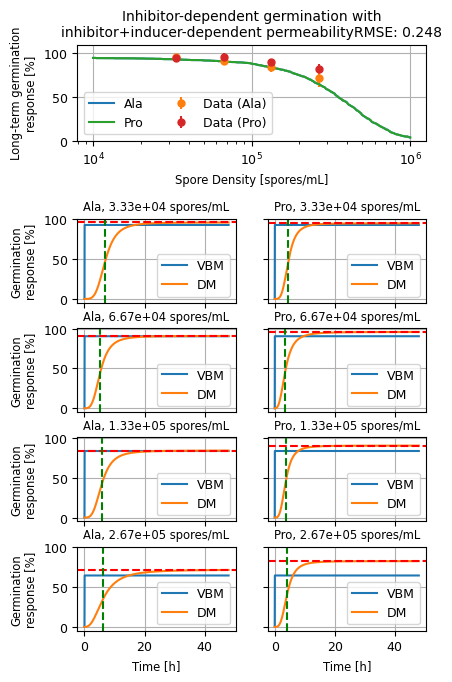

In [25]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inhibitor_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inhibitor_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [26]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inducer-dependent germination with inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.58 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=4983.961183118
23.40 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=4983.961183118
33.72 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=4983.961183118
45.72 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=4983.961183118
57.02 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 0.0000), fitness=2722.288342980
68.77 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=2722.288342980
80.69 secs, 14 evals,

Dict{Any, Any} with 10 entries:
  :b_max => [0.134377]
  :σ_ψ   => [1.11248e-5]
  :K_cI  => [0.0909847]
  :μ_ω   => [8.6674, 0.227932]
  :K_cC  => [0.00561562, 0.018607]
  :μ_ψ   => [0.146031]
  :s_max => [4711.68, 4667.5]
  :Pₛ    => [0.000461817]
  :Pₛ_cs => [0.004393, 0.00288388]
  :σ_ω   => [5.25705, 0.132146]

0.5298693759794773


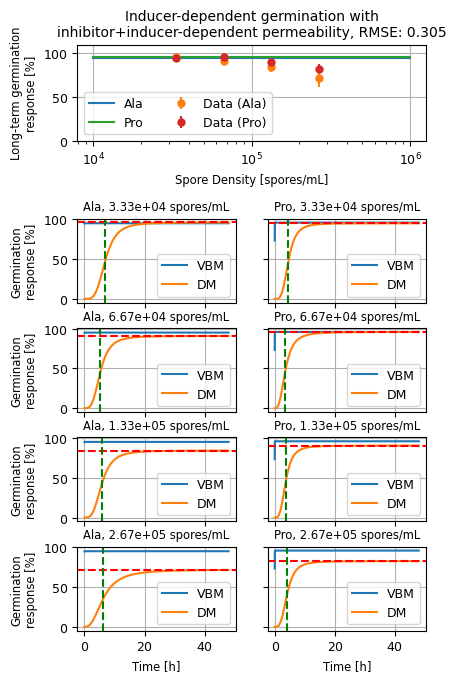

In [27]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [28]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.46 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
23.69 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
35.21 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
47.36 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
59.46 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
71.22 secs, 12 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
82.66 secs, 14 evals, 7 steps, impro

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.0159534]
  :μ_ψ   => [0.922563]
  :μ_ω   => [0.62429, 1.77047]
  :Pₛ    => [0.000464653]
  :σ_ω   => [0.0108352, 0.000450694]
  :σ_γ   => [7.21881e-9]
  :b_max => [0.554786]
  :K_cI  => [0.0187376]
  :K_cC  => [0.000848063, 0.0135522]
  :μ_γ   => [8.40785e-5]
  :s_max => [4276.37, 3863.39]
  :Pₛ_cs => [0.00608551, 0.00229103]

0.33293635360495333


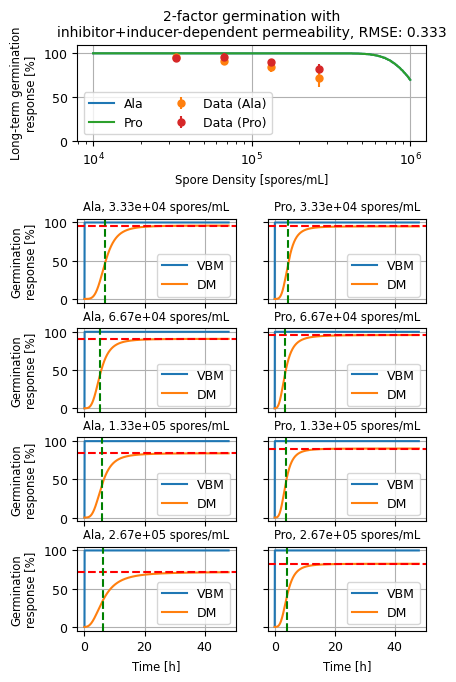

In [29]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.2.4. Inducer-dependent cell wall permeability and inhibitor-dependent induction threshold (AE)

This scenario follows the ODEs from Section 1, but the germination criterion is with respect to a dynamic inhibitor-dependent induction threshold. The two triggering variants are
- 2-factor germination;
- inducer-dependent germination.

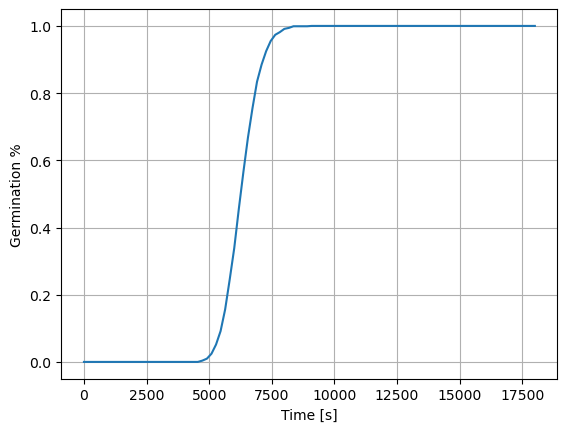

In [ ]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inducer_inhibitor_thresh_inducer_perm", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [35]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_thresh_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_thresh_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inducer-dependent germination with inhibitor-dependent induction threshold and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
12.51 secs, 2 evals, 1 steps, fitness=5064.306714978
24.99 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 1.0000), fitness=5064.306714978
37.36 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=5064.306714978
50.08 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=5064.306714978
62.16 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 0.0000), fitness=5064.306714978
74.10 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=3455.289317412
87.11 secs, 14 evals, 7 step

Dict{Any, Any} with 10 entries:
  :σ_ψ   => [0.528257]
  :K_cI  => [0.0317147]
  :μ_ω   => [0.279299, 7.24705]
  :k_I   => [1.39839]
  :K_cC  => [0.00714505, 0.0818153]
  :μ_ψ   => [0.698352]
  :s_max => [9168.16, 466.909]
  :Pₛ    => [0.000969824]
  :Pₛ_cs => [0.000411039, 0.00432452]
  :σ_ω   => [0.000327703, 0.126637]

0.6571994862114157


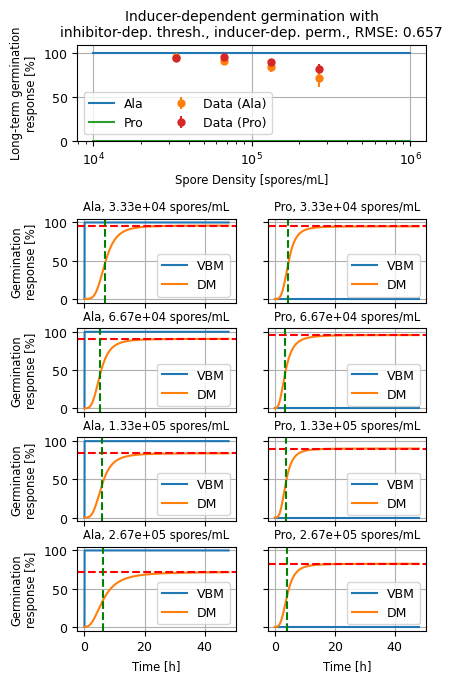

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_thresh_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_thresh_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [36]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_thresh_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_thresh_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inhibitor-dependent induction threshold and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
12.05 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
24.35 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
30.37 secs, 5 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
41.95 secs, 7 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
48.47 secs, 8 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
60.54 secs, 10 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
71

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.0731276]
  :μ_ψ   => [0.191819]
  :μ_ω   => [0.146206, 5.12824]
  :σ_ω   => [0.0885846, 0.0741296]
  :Pₛ    => [0.000137054]
  :k_I   => [86.8143]
  :σ_γ   => [6.21532e-8]
  :K_cI  => [0.0336191]
  :K_cC  => [0.0401818, 0.096745]
  :μ_γ   => [2.76696e-5]
  :s_max => [8006.66, 4532.81]
  :Pₛ_cs => [1.39041e-5, 0.00427862]

0.6289035773359831


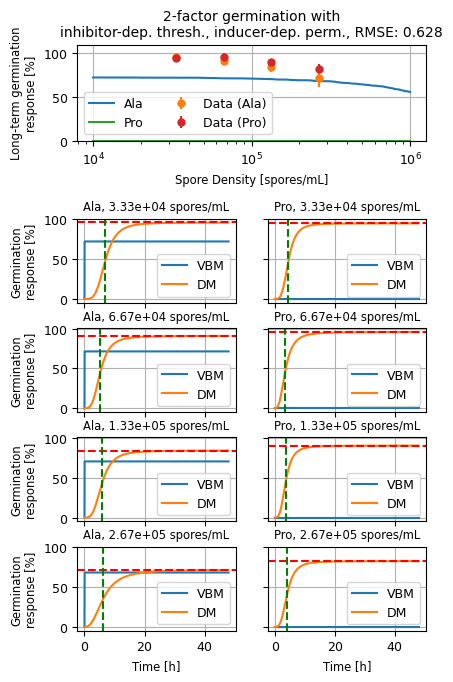

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_thresh_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_thresh_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.2.5. Inhibitor-dependent induction signal and inducer-dependent inhibition threshold (BC)

Since none of the interactions affects the inducer or inhibitor concentration, the two compound amounts can be computed analytically. However, the inhibition threshold changes dynamically with the inducer signal, which in the case of a 2-factor germination leads to the probability equation:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{\omega}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-ks{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_\omega=\frac{s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\omega}}{\sigma_{\omega}}.
\end{equation}
$$

Another option is a solely inhibitor-dependent germination, yielding

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}}.
\end{equation}
$$

  0.059939 seconds (793.38 k allocations: 57.382 MiB, 30.80% gc time)
  0.001604 seconds (3.70 k allocations: 7.045 MiB)


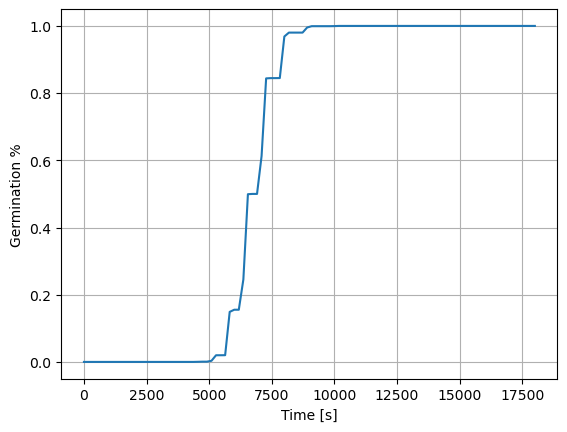

In [ ]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("inhibitor_thresh_inducer_signal", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [55]:
max_steps = 10
params_opt, rmse = fit_model_to_data("inhibitor_thresh_inducer_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_inhibitor_thresh_inducer_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 10

Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
0.62 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=697.905376739
1.20 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=674.401041201
1.92 secs, 7 evals, 4 steps, improv/step: 0.750 (last = 0.5000), fitness=591.292677324
2.46 secs, 9 evals, 5 steps, improv/step: 0.600 (last = 0.0000), fitness=554.881441091
3.43 secs, 13 evals, 7 steps, improv/step: 0.571 (last = 0.5000), fitness=269.900280815
4.13 secs, 16 evals, 9 steps, improv/step: 0.444 (last = 0.0000), fitness=269.900280815
4.67 secs, 18 evals, 10 steps, improv/step: 0.500 (last = 1.0000), fitness=269.900280815

Optimization stopped after 11 steps and 5.16 secon

Dict{Any, Any} with 10 entries:
  :σ_γ   => [8.62717e-6]
  :k_C   => [0.00691098, 0.0303602]
  :σ_ψ   => [0.000511613]
  :K_I   => [0.0118106]
  :n     => [1.99447, 1.92524]
  :K_cC  => [0.0961044, 0.00845979]
  :μ_γ   => [1.54014e-5]
  :Pₛ    => [0.000246482]
  :μ_ψ   => [0.753168]
  :Pₛ_cs => [0.00728931, 0.00979901]

0.16988114534038604


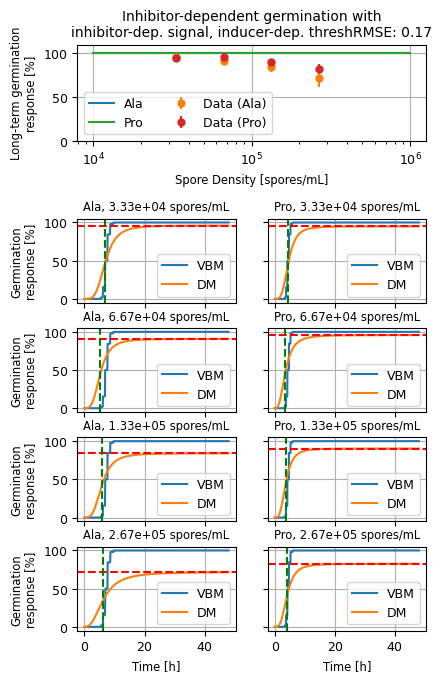

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_inhibitor_thresh_inducer_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("inhibitor_thresh_inducer_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [8]:
max_steps = 10
params_opt, rmse = fit_model_to_data("combined_inhibitor_thresh_inducer_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_combined_inhibitor_thresh_inducer_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 10
Model: 2-factor germination with inducer-dependent inhibition threshold and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
0.70 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
1.42 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
2.05 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
2.67 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=4995.297200443
3.47 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 0.0000), fitness=4995.297200443
4.19 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 0.0000), fitness=2809.634321214
5.20 secs, 15 evals, 8

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.0932034]
  :K_I   => [0.657748]
  :n     => [1.99839, 1.3857]
  :μ_ψ   => [0.902022]
  :μ_ω   => [0.982245, 0.0155085]
  :Pₛ    => [0.000122023]
  :σ_ω   => [0.00430397, 1.51421e-5]
  :σ_γ   => [1.0512e-7]
  :k_C   => [13.6403, 0.594611]
  :K_cC  => [0.0108678, 0.0393716]
  :μ_γ   => [9.92891e-5]
  :Pₛ_cs => [0.00374237, 0.00585947]

0.5559204682496467


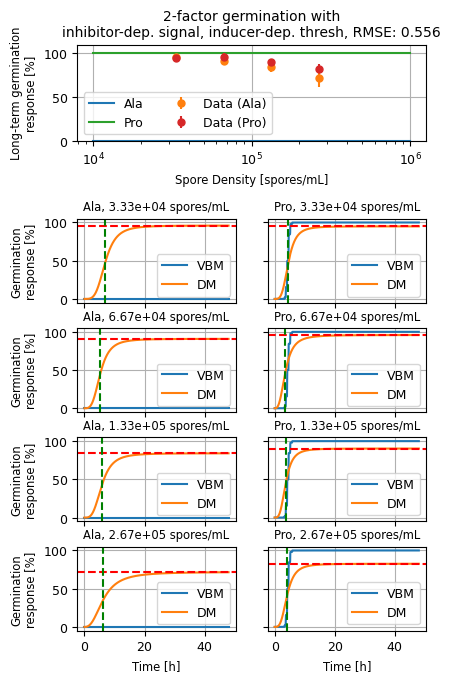

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_combined_inhibitor_thresh_inducer_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("combined_inhibitor_thresh_inducer_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.2.6. Inhibitor-dependent cell wall permeability and inducer-dependent inhibition threshold (BD)

The ODEs for this scenario are as in 2.1.2. and the germination criterion involves a dynamic threshold shifted by the inductive signal. The germination triggering occurs through
- 2-factor germination;
- inhibitor-dependent germination.

In [24]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inducer-dependent inhibition threshold and inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.64 secs, 2 evals, 1 steps, fitness=612.398811155
23.19 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 1.0000), fitness=612.398811155
35.54 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=612.398811155
47.46 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=612.398811155
58.59 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=612.398811155
69.98 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=612.398811155
81.80 secs, 14 evals, 7 steps, 

Dict{Any, Any} with 10 entries:
  :σ_γ   => [4.97818e-11]
  :b_max => [0.998561]
  :σ_ψ   => [0.00485316]
  :K_cI  => [0.05851]
  :k_C   => [1.00016, 1.13997]
  :K_cC  => [0.0257714, 0.024348]
  :μ_ψ   => [0.865322]
  :Pₛ    => [0.000891994]
  :μ_γ   => [1.03051e-6]
  :Pₛ_cs => [0.00980637, 0.0014362]

0.16847530310934924


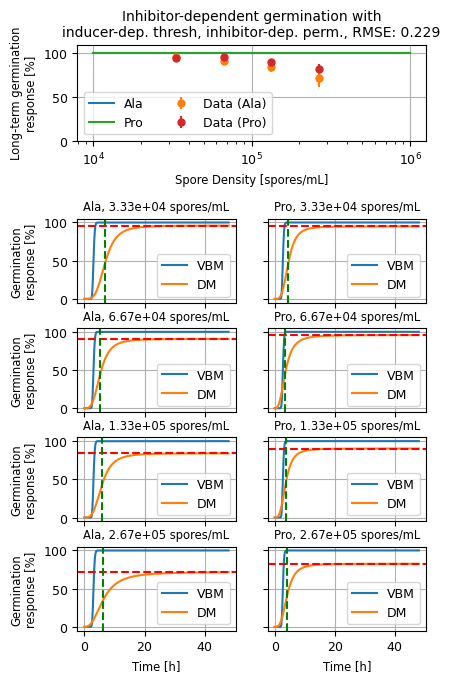

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [26]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inducer-dependent inhibition threshold and inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
14.01 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
27.77 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
39.94 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 0.0000), fitness=5213.806775765
45.95 secs, 7 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=5213.806775765
57.74 secs, 9 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=5213.806775765
69.31 secs, 11 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=5213.

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.000121525]
  :μ_ψ   => [0.758225]
  :μ_ω   => [6.23447, 0.0531474]
  :Pₛ    => [0.000180343]
  :σ_ω   => [1.09097, 0.0321477]
  :σ_γ   => [2.86484e-7]
  :b_max => [0.00159168]
  :k_C   => [69.2141, 1.4846]
  :K_cI  => [0.0107959]
  :K_cC  => [0.0882392, 0.0983761]
  :μ_γ   => [4.16496e-5]
  :Pₛ_cs => [0.0098676, 0.00740277]

0.5509100412715596


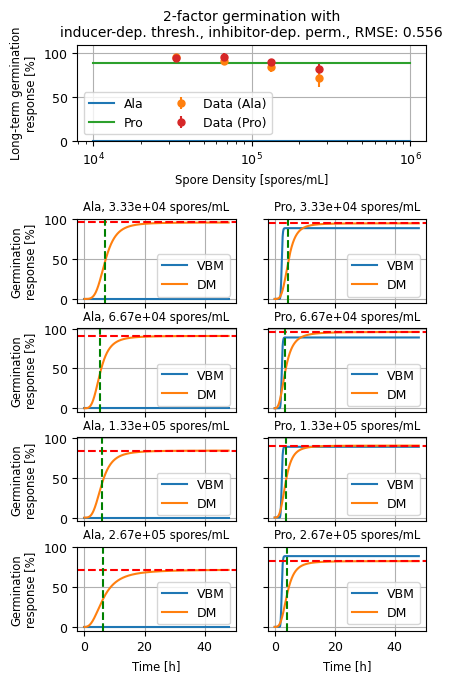

In [27]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.2.7. Inducer-dependent inhibition threshold and inhibitor-dependent induction threshold (BE)

The inducer/inhibitor concentrations in this case are not influenced by each other, but both thresholds are affected. This results in an analytical solution:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{\omega_0}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-k_1s{(\xi, \kappa)}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_{\omega_0}=\frac{s{(\xi, \kappa)}-k_2c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}-\mu_{\omega_0}}{\sigma_{\omega_0}}.
\end{equation}
$$

Note the two _different_ proportionality constants for the respective threshold shifts ($k_1$ and $k_2$).

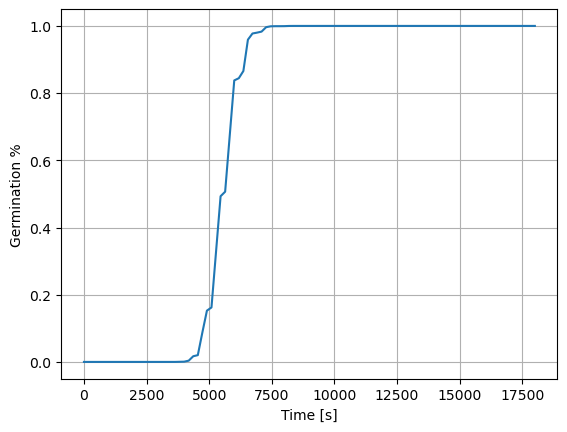

In [5]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("combined_inhibitor_thresh_inducer_thresh", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [7]:
max_steps = 10
params_opt, rmse = fit_model_to_data("combined_inhibitor_thresh_inducer_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_combined_inhibitor_thresh_inducer_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 10
Model: inhibitor-modulated induction threshold / inducer-modulated inhibition threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
0.75 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.5000), fitness=4719.169065558
1.54 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=4719.169065558
2.19 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=4719.169065558
2.80 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=4719.169065558
3.64 secs, 16 evals, 8 steps, improv/step: 0.750 (last = 0.5000), fitness=4719.169065558

Optimization stopped after 11 steps and 4.43 seconds
Termination reason: Max number of steps (10) reached
Steps per second = 2.48
Fun

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.0696137]
  :μ_ψ   => [0.916274]
  :μ_ω   => [0.54784, 0.157042]
  :Pₛ    => [0.00092781]
  :σ_ω   => [0.00260224, 0.0834062]
  :k_I   => [32.4943, 322.118]
  :σ_γ   => [1.20676e-7]
  :k_C   => [5.62969, 0.216928]
  :K_cC  => [0.0486972, 0.0300396]
  :μ_γ   => [9.12994e-5]
  :Pₛ_cs => [0.00661654, 0.00964346]

0.5558509140958857


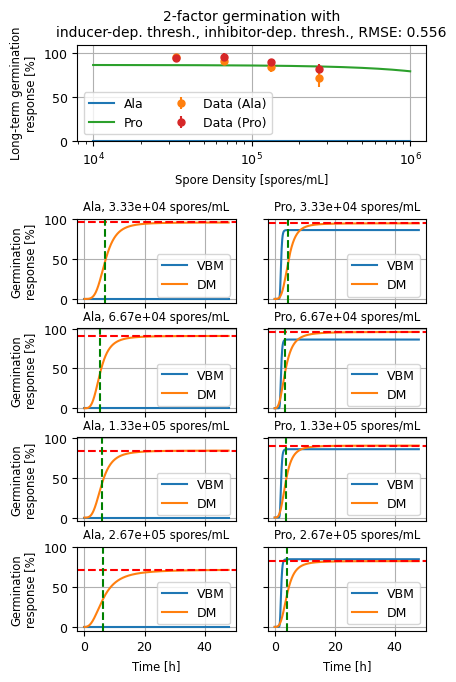

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_combined_inhibitor_thresh_inducer_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("combined_inhibitor_thresh_inducer_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.2.8. Inducer-dependent cell wall permeability and induction signal (CD)

The ODEs for this system are as in 2.1.2., but additionally the inducer concentration is multiplied by the inhibitor effect before performing the induction threshold check. This applies to
- 2-factor germination;
- inducer-dependent germination.

In [17]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inducer-dependent inhibition threshold and inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
11.30 secs, 2 evals, 1 steps, fitness=415.748795285
22.40 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 1.0000), fitness=295.894447564
33.99 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 0.0000), fitness=295.894447564
45.56 secs, 8 evals, 4 steps, improv/step: 0.250 (last = 0.0000), fitness=295.894447564
57.59 secs, 10 evals, 5 steps, improv/step: 0.400 (last = 1.0000), fitness=295.894447564
70.18 secs, 12 evals, 6 steps, improv/step: 0.333 (last = 0.0000), fitness=295.894447564
82.14 secs, 14 evals, 7 steps, 

Dict{Any, Any} with 10 entries:
  :σ_γ   => [2.05423e-7]
  :b_max => [0.841283]
  :σ_ψ   => [0.746968]
  :K_cI  => [0.0476598]
  :k_C   => [0.135133, 1.99986]
  :K_cC  => [0.00351156, 0.0850926]
  :μ_ψ   => [0.746971]
  :Pₛ    => [0.000173075]
  :μ_γ   => [2.50795e-5]
  :Pₛ_cs => [0.00947396, 0.00951153]

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [18]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inhibitor-dependent germination with inducer-dependent inhibition threshold and inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
24.01 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
48.54 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
77.21 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 0.0000), fitness=4819.163665638
105.64 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=4819.163665638
129.70 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=4819.163665638
155.35 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=4

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.0154582]
  :μ_ψ   => [0.268992]
  :μ_ω   => [6.39647, 0.47948]
  :Pₛ    => [0.000459615]
  :σ_ω   => [0.00702794, 0.289488]
  :σ_γ   => [5.08991e-7]
  :b_max => [0.881778]
  :k_C   => [5.08515, 0.00263482]
  :K_cI  => [0.0867236]
  :K_cC  => [0.0224349, 0.0021166]
  :μ_γ   => [9.33094e-5]
  :Pₛ_cs => [0.00238573, 0.00209576]

0.5509996561714672


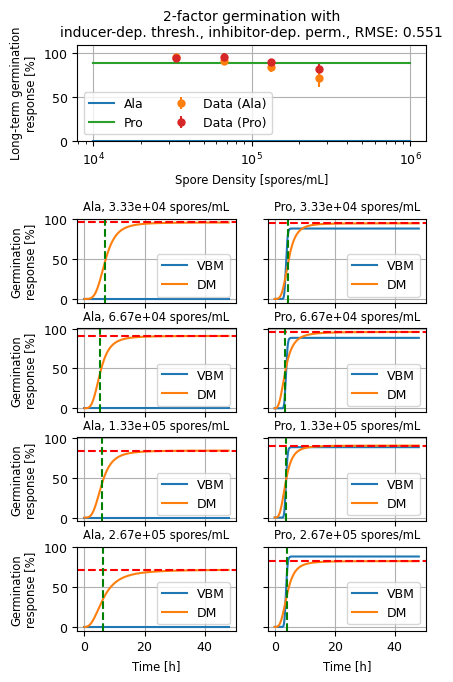

In [19]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.2.9. Inhibitor-dependent cell wall permeability and induction threshold (DE)

The ODEs for this system are as in 2.1.2., with an inhibitor-dependent induction threshold changing over time. This applies to
- 2-factor germination;
- inducer-dependent germination.

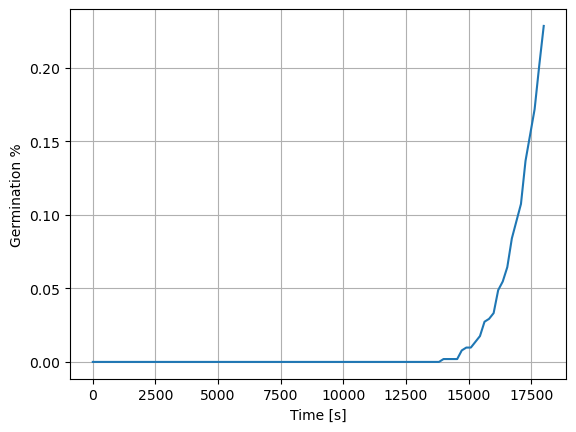

In [65]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inducer_inhibitor_perm_thresh", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [5]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_perm_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inhibitor-dependent inhibitor/inducer permeability and induction threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.18 secs, 2 evals, 1 steps, fitness=5285.132840981
10.93 secs, 4 evals, 2 steps, fitness=5117.927381969
15.27 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 1.0000), fitness=5117.927381969
20.10 secs, 8 evals, 4 steps, improv/step: 0.250 (last = 0.0000), fitness=3455.289317412
25.75 secs, 10 evals, 5 steps, improv/step: 0.400 (last = 1.0000), fitness=3455.289317412
31.53 secs, 12 evals, 6 steps, improv/step: 0.500 (last = 1.0000), fitness=3455.289317412
36.48 secs, 14 evals, 7 steps, improv/step: 0.571 (last = 1.0000), fitness=3455.28

Dict{Any, Any} with 10 entries:
  :b_max => [0.0258541]
  :σ_ψ   => [0.0568557]
  :K_cI  => [0.0294237]
  :μ_ω   => [9.21733, 0.071642]
  :k_I   => [1.54585, 173.96]
  :K_cC  => [0.00624865, 0.0899431]
  :μ_ψ   => [0.168166]
  :Pₛ    => [0.000582287]
  :σ_ω   => [0.00515393, 1.46667e-5]
  :Pₛ_cs => [0.00801507, 0.00999746]

0.5516717213499613


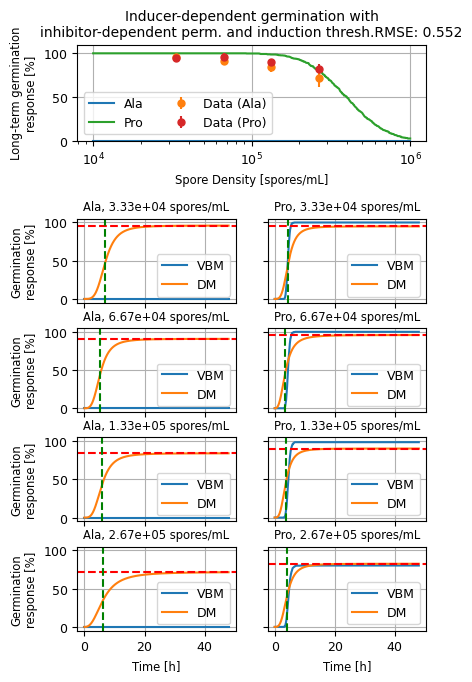

In [6]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_perm_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [68]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_perm_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_perm_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inhibitor-dependent inhibitor/inducer permeability and induction threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.43 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
10.91 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=5115.035961941
16.88 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=5115.035961941
22.17 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=5115.035961941
27.74 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=2591.772878235
32.92 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=2591.772878235
35.87 secs

Dict{Any, Any} with 12 entries:
  :σ_ψ   => [0.000549949]
  :μ_ψ   => [0.801221]
  :μ_ω   => [3.60782, 0.0834772]
  :Pₛ    => [0.000366459]
  :σ_ω   => [0.00828163, 0.000251093]
  :k_I   => [0.276219, 10.3858]
  :σ_γ   => [1.43049e-8]
  :b_max => [0.169621]
  :K_cI  => [0.0430999]
  :K_cC  => [0.0315884, 0.00874491]
  :μ_γ   => [9.66837e-5]
  :Pₛ_cs => [0.00210186, 0.00559347]

0.5558534030907895


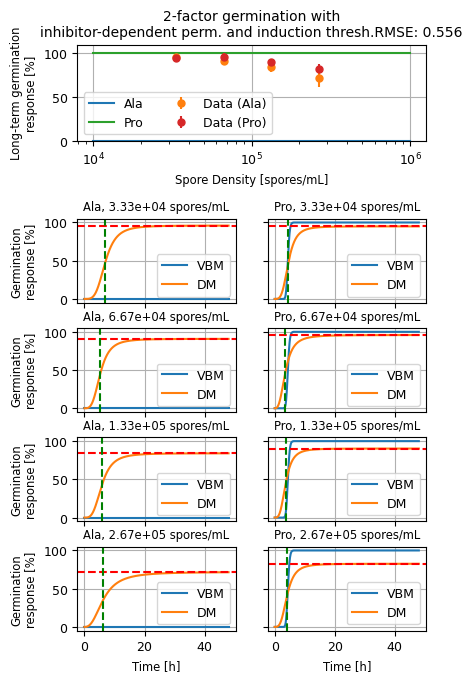

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_perm_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_perm_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

### 2.3. Triple-interaction models

#### 2.3.1. Inducer-dependent cell wall permeability and inhibition threshold, inhibitor-dependent induction signal (ABC)

The ODEs are as in 2.2.2., with the inhibition threshold being dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

In [5]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm_thresh_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inducer-dependent germination with inducer-dependent permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
4.54 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
10.75 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
16.23 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
22.01 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
24.92 secs, 9 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
30.92 secs, 11 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
33.81 secs, 12 e

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.141759]
  :n     => [1.47093, 2.06669]
  :μ_ψ   => [0.743375]
  :μ_ω   => [5.95429, 1.0e-6]
  :Pₛ    => [0.000976794]
  :σ_ω   => [0.0272421, 2.56336e-7]
  :k_C   => [53.7583, 193.924]
  :K_cI  => [0.0902723]
  :K_cC  => [0.0181207, 1.0e-8]
  :s_max => [591.318, 3084.78]
  :Pₛ_cs => [0.0020706, 0.00826905]

0.5839504399596717


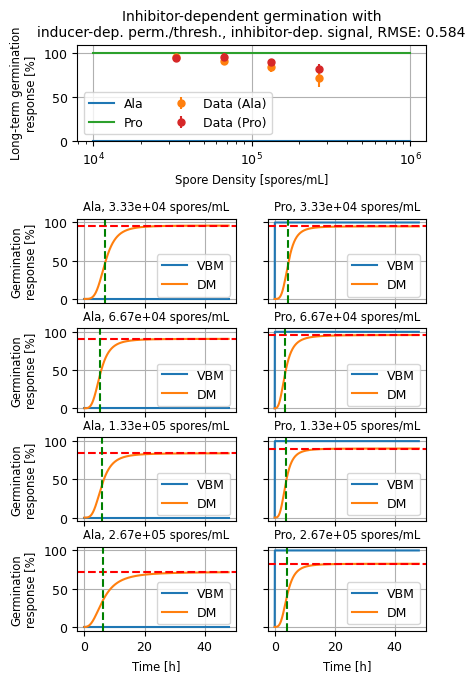

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm_thresh_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [3]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_thresh_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inducer-dependent permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
4.70 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=225.546603706
9.54 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=225.546603706
14.97 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 0.0000), fitness=225.546603706
20.39 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=225.546603706
25.44 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=225.546603706
30.86 secs, 12 evals, 6 steps, improv/step: 0.500 (last = 0.0000), fitness=225.546603706
35.55 secs, 14 evals, 7 steps, 

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.191493]
  :n     => [2.3181, 2.62537]
  :μ_ψ   => [0.191494]
  :μ_ω   => [7.41116e-5, 2.88298e-5]
  :σ_ω   => [1.05575e-5, 8.64562e-8]
  :Pₛ    => [0.000277359]
  :σ_γ   => [3.67447e-5]
  :k_C   => [3.28028, 2.64089]
  :K_cI  => [0.0333049]
  :K_cC  => [0.0988244, 0.0010432]
  :μ_γ   => [6.05817e-5]
  :s_max => [0.0192299, 0.916715]
  :Pₛ_cs => [6.61905e-5, 9.73047e-5]

0.11886560829740518


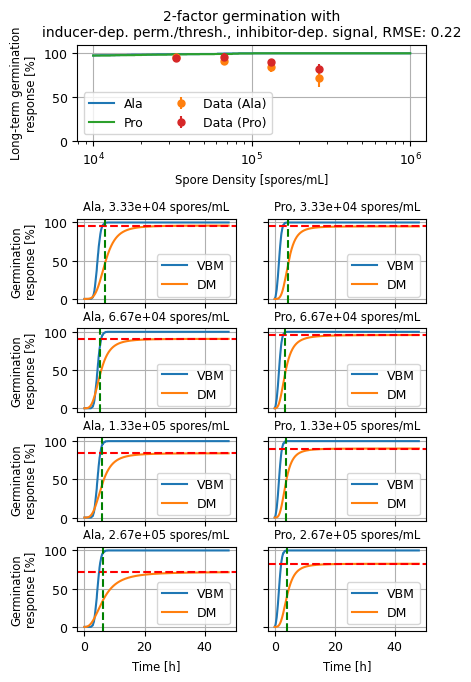

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_thresh_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.2. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibition threshold (ABD)

The ODEs are as in 2.2.3, with the inhibition threshold being dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

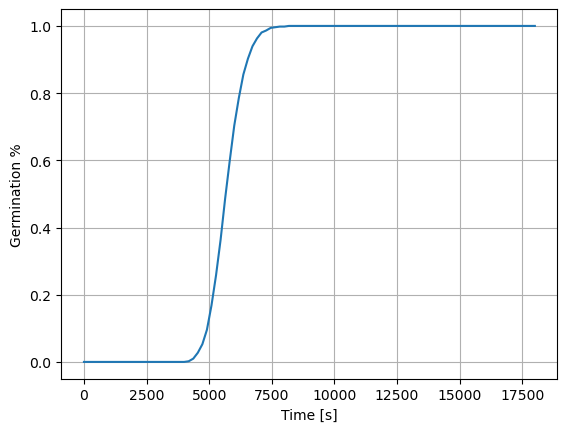

In [15]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inducer_perm_thresh_inhibitor_perm", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [11]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inducer-dependent inhibition threshold and inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.33 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=3455.289317412
10.32 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=886.772924414
16.48 secs, 6 evals, 3 steps, improv/step: 0.333 (last = 0.0000), fitness=886.772924414
21.80 secs, 8 evals, 4 steps, improv/step: 0.250 (last = 0.0000), fitness=886.772924414
26.97 secs, 10 evals, 5 steps, improv/step: 0.200 (last = 0.0000), fitness=886.772924414
32.73 secs, 12 evals, 6 steps, improv/step: 0.333 (last = 1.0000), fitne

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.00534226]
  :μ_ψ   => [0.524338]
  :Pₛ    => [0.000950193]
  :σ_γ   => [2.21286e-5]
  :b_max => [0.615283]
  :k_C   => [1.4376, 2.32592]
  :K_cI  => [0.0382889]
  :K_cC  => [0.0407068, 0.0970383]
  :μ_γ   => [5.29459e-5]
  :s_max => [7368.62, 452.439]
  :Pₛ_cs => [0.00193494, 0.00478487]

0.33293635360495333


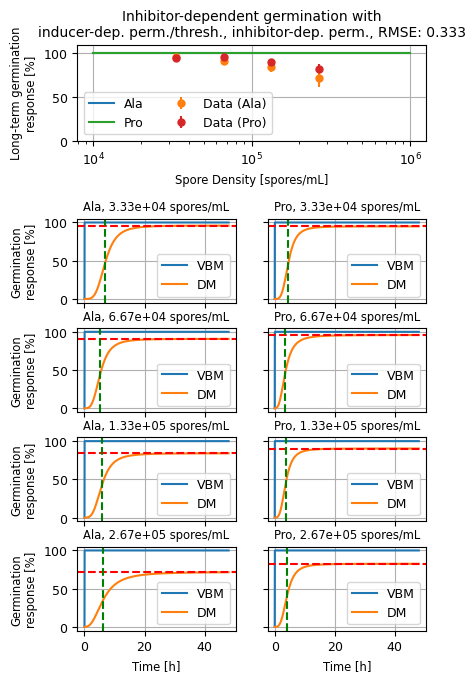

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [9]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_thresh_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inducer-dependent inhibition threshold and inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.24 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
10.63 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
16.33 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
21.44 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
25.88 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
31.07 secs, 12 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5296

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.297971]
  :μ_ψ   => [0.932977]
  :μ_ω   => [0.0904474, 8.36244]
  :Pₛ    => [0.000734797]
  :σ_ω   => [0.0548548, 0.000401357]
  :σ_γ   => [2.71197e-8]
  :b_max => [0.824863]
  :k_C   => [10.5937, 0.108872]
  :K_cI  => [0.0491277]
  :K_cC  => [0.0705021, 0.0537798]
  :μ_γ   => [9.29002e-5]
  :s_max => [8828.76, 7182.98]
  :Pₛ_cs => [0.00414609, 0.00205736]

0.6289678456100573


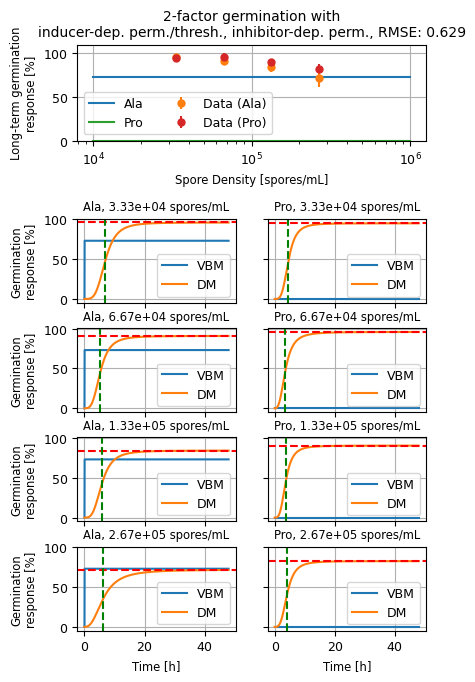

In [10]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_thresh_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.3. Inducer-dependent cell wall permeability and inhibition threshold, inhibitor-dependent induction threshold (ABE)

The ODEs are as in Section 1 and both thresholds are dynamically modulated by the opposite actor. The only triggering variant is 2-factor germination.

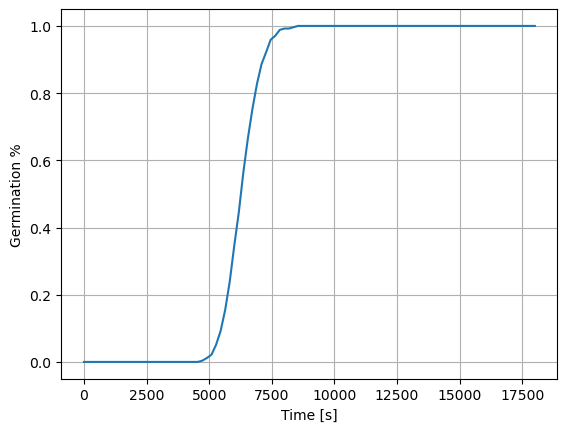

In [4]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inducer_perm_thresh_inhibitor_thresh", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [7]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_thresh_inhibitor_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrowest, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inducer-dependent inhibitor/inducer permeability and inhibition threshold and inhibitor-dependent induction threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.44 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=2698.352312696
11.27 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=2698.352312696
14.01 secs, 5 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=2698.352312696
19.81 secs, 7 evals, 4 steps, improv/step: 0.750 (last = 0.0000), fitness=2698.352312696
25.56 secs, 9 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=2642.984815777
31.35 secs, 11 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fi

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.807736]
  :μ_ψ   => [0.807741]
  :μ_ω   => [8.70741e-5, 8.20574e-5]
  :σ_ω   => [8.75016e-9, 1.62267e-7]
  :Pₛ    => [0.000156568]
  :k_I   => [3.8083, 0.260848]
  :σ_γ   => [1.05793e-5]
  :k_C   => [6.82401, 1.37687]
  :K_cI  => [0.0541882]
  :K_cC  => [0.0841887, 0.0886883]
  :μ_γ   => [4.35223e-5]
  :s_max => [0.0411149, 0.660189]
  :Pₛ_cs => [5.145e-5, 4.96696e-6]

0.15417504586611525


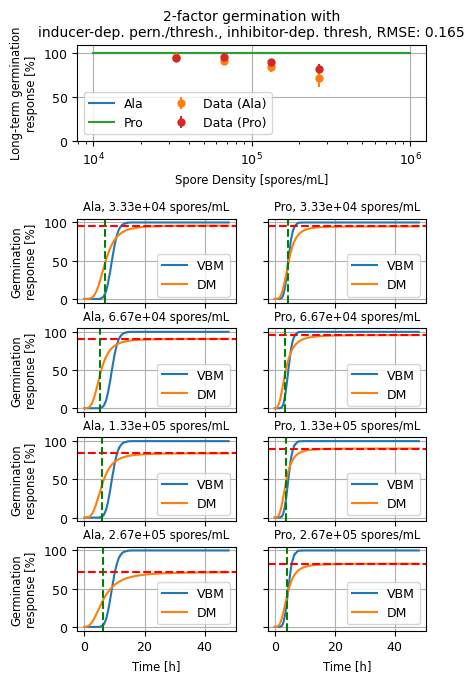

In [8]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_thresh_inhibitor_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_thresh_inhibitor_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.4. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal (ACD)

The ODE system is as follows:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$  
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-b_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{I}}+c_{\textrm{in}}^{\textrm{I}}}\right)A.
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

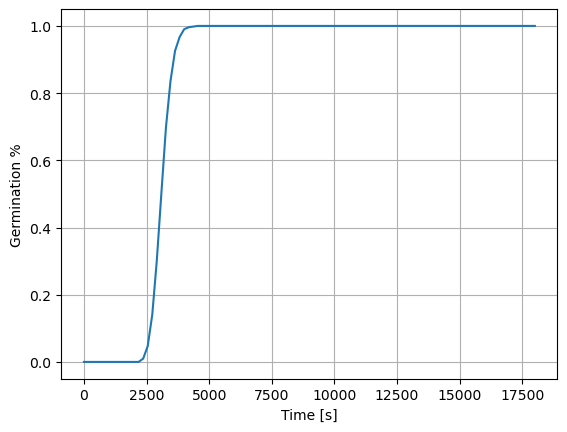

In [30]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inhibitor_inducer_perm_inhibitor_signal", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [32]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inhibitor_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inhibitor_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inducer/inhibitor-dependent inhibitor/inducer permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
6.53 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=721.894026987
13.04 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=721.894026987
18.79 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=721.894026987
24.98 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=721.894026987
31.34 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=583.821990528
37.03 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=276.7

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.000194115]
  :n     => [2.99901, 2.0102]
  :μ_ψ   => [0.982039]
  :Pₛ    => [0.000579591]
  :σ_γ   => [2.13237e-5]
  :b_max => [0.723642]
  :K_cI  => [0.00116901]
  :K_cC  => [0.0986299, 0.0722378]
  :μ_γ   => [3.51603e-5]
  :s_max => [5978.78, 7511.29]
  :Pₛ_cs => [0.000112701, 0.0028695]

0.08390343418650871


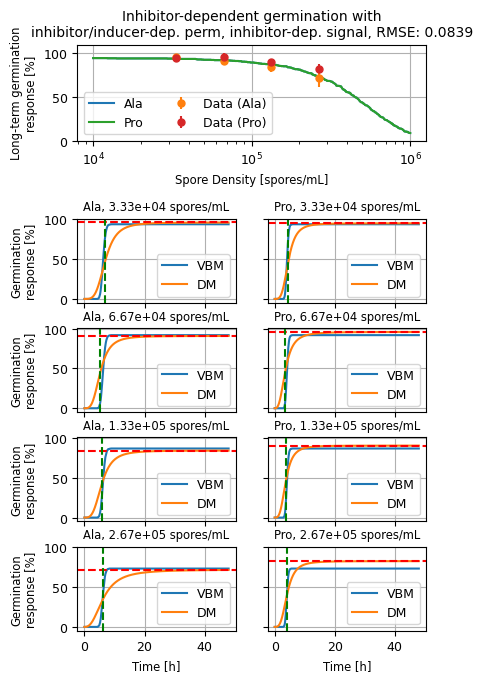

In [3]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inhibitor_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inhibitor_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [35]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inducer/inhibitor-dependent inhibitor/inducer permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
4.97 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
10.61 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
15.84 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
21.62 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
27.13 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 0.0000), fitness=5262.436162340
32.90 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.000178263]
  :n     => [1.4143, 2.28824]
  :μ_ψ   => [0.63666]
  :μ_ω   => [0.680474, 8.86628]
  :Pₛ    => [0.000617872]
  :σ_ω   => [0.412505, 0.00411627]
  :b_max => [0.665121]
  :K_cI  => [0.00611068]
  :K_cC  => [0.000698133, 0.0809312]
  :s_max => [5108.71, 7915.63]
  :Pₛ_cs => [0.0090894, 0.00585431]

0.6289687932674024


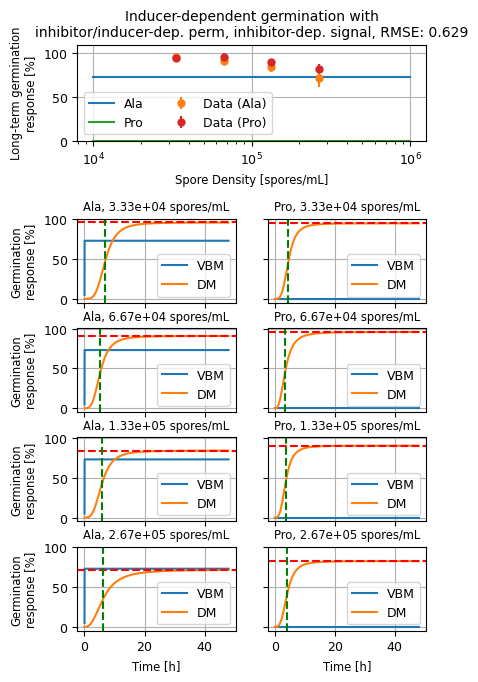

In [4]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [34]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_inducer_perm_inhibitor_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm_inhibitor_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inducer/inhibitor-dependent inhibitor/inducer permeability and inhibitor-dependent induction signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.58 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5286.591966143
11.33 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5138.018445731
17.62 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5138.018445731
23.36 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5138.018445731
29.28 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5138.018445731
35.36 secs, 12 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=4543.214993

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.17906]
  :n     => [1.32909, 1.55217]
  :μ_ψ   => [0.372017]
  :μ_ω   => [0.203416, 0.143435]
  :Pₛ    => [0.000613789]
  :σ_ω   => [2.09046e-5, 0.0869831]
  :σ_γ   => [4.35373e-7]
  :b_max => [0.0943951]
  :K_cI  => [0.0683933]
  :K_cC  => [0.0391573, 0.0298949]
  :μ_γ   => [3.98152e-5]
  :s_max => [8073.29, 5672.94]
  :Pₛ_cs => [0.00100922, 0.00374256]

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm_inhibitor_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_inducer_perm_inhibitor_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.5. Inducer-dependent cell wall permeability, inhibitor-dependent induction signal and threshold (ACE)

The ODEs are as in 2.2.2. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

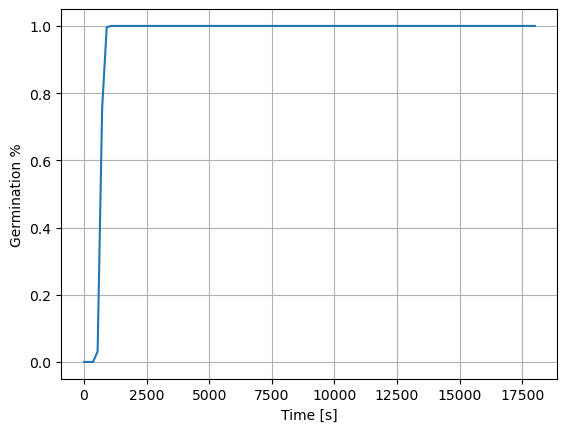

In [37]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inducer_inducer_perm_inhibitor_thresh_signal", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [5]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inducer_perm_inhibitor_thresh_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inducer_perm_inhibitor_thresh_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inducer-dependent germination with inducer-dependent permeability and inhibitor-dependent induction threshold and signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.22 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=4341.145781422
10.19 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=4341.145781422
15.39 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=4341.145781422
20.60 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.985067962
22.66 secs, 9 evals, 5 steps, improv/step: 0.800 (last = 0.0000), fitness=2727.985067962
27.44 secs, 11 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=2727.985067962
33

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.00231315]
  :n     => [2.93802, 1.44504]
  :μ_ψ   => [0.616405]
  :μ_ω   => [3.33932, 0.166715]
  :Pₛ    => [0.000781617]
  :σ_ω   => [0.00440059, 0.100964]
  :k_I   => [0.0319809, 2.10643]
  :K_cI  => [0.0786041]
  :K_cC  => [0.0597082, 0.0284776]
  :s_max => [4436.89, 5532.18]
  :Pₛ_cs => [0.00226084, 0.000853116]

0.570109559297355


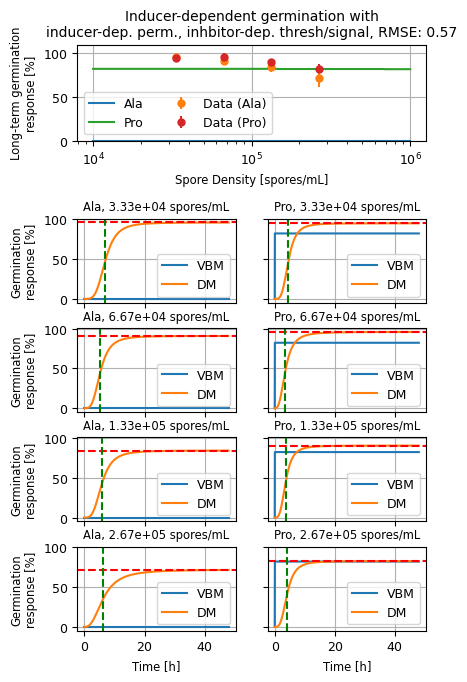

In [6]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inducer_perm_inhibitor_thresh_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inducer_perm_inhibitor_thresh_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [7]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm_inhibitor_thresh_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm_inhibitor_thresh_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inducer-dependent permeability and inhibitor-dependent induction threshold and signal
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
4.45 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
10.61 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
15.95 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
21.14 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
26.30 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 0.0000), fitness=2727.984930633
31.46 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=2727.984930633
35.99 secs

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.0993117]
  :n     => [1.31404, 2.3447]
  :μ_ψ   => [0.726541]
  :μ_ω   => [0.376965, 0.0886078]
  :σ_ω   => [0.184478, 1.05612e-5]
  :Pₛ    => [0.000230833]
  :k_I   => [0.0516082, 374.54]
  :σ_γ   => [2.30514e-6]
  :K_cI  => [0.0924053]
  :K_cC  => [0.00824401, 0.0510697]
  :μ_γ   => [2.96251e-5]
  :s_max => [1.62285, 4594.37]
  :Pₛ_cs => [0.00968499, 0.00227554]

0.196339990590449


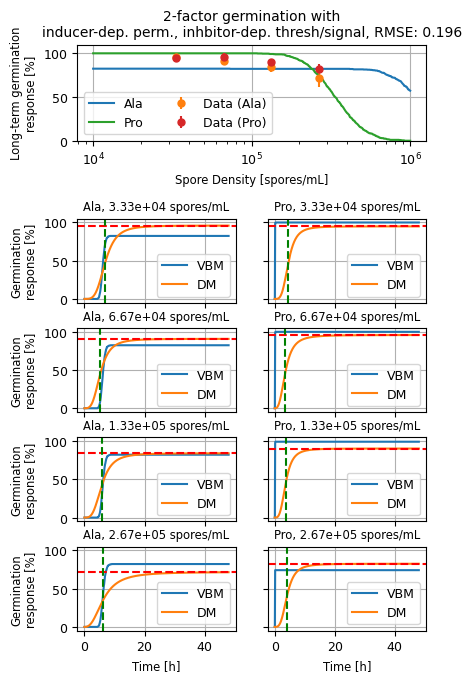

In [8]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm_inhibitor_thresh_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm_inhibitor_thresh_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.6. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction threshold (ADE)

The ODEs are as in 2.2.3. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

In [ ]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_inducer_perm_inhibitor_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm_inhibitor_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
9.44 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
18.33 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
27.05 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
31.66 secs, 7 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
40.23 secs, 9 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
49.26 secs, 11 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
57.83 secs, 13 evals, 7 step

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.000346196]
  :μ_ψ   => [0.440349]
  :Pₛ    => [0.000175075]
  :k_I   => [0.0824773, 0.413302]
  :σ_γ   => [1.76548e-8]
  :b_max => [0.532366]
  :K_cI  => [0.0305792]
  :K_cC  => [0.0665259, 0.0776072]
  :μ_γ   => [7.08715e-5]
  :s_max => [2953.53, 1244.18]
  :Pₛ_cs => [0.00096426, 0.00202457]

0.33293635360495333


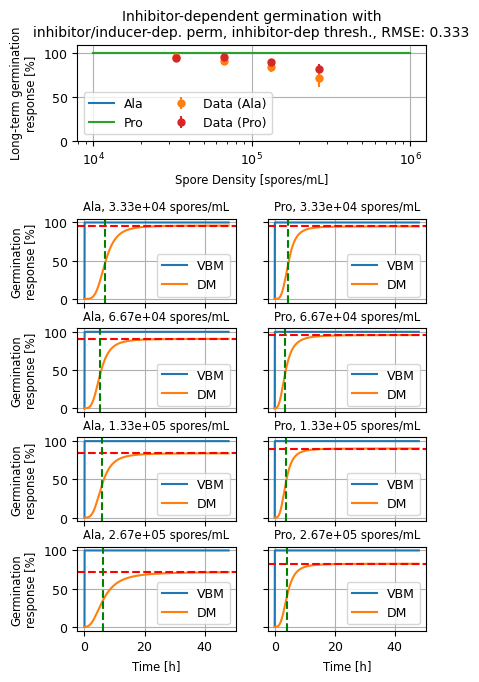

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_inducer_perm_inhibitor_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_inducer_perm_inhibitor_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [5]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_inducer_perm_inhibitor_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm_inhibitor_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inhibitor- and inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.15 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
9.17 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
14.72 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
20.42 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
25.89 secs, 10 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
30.98 secs, 12 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=2727.984930633
36.50 secs, 14 evals, 7 steps, im

Dict{Any, Any} with 13 entries:
  :σ_ψ   => [0.00304314]
  :μ_ψ   => [0.244164]
  :μ_ω   => [8.63514, 0.0381941]
  :Pₛ    => [0.000556631]
  :σ_ω   => [0.0383947, 1.81714e-5]
  :k_I   => [0.160138, 25.6063]
  :σ_γ   => [2.08458e-5]
  :b_max => [0.0399595]
  :K_cI  => [0.033866]
  :K_cC  => [0.0302306, 0.0420896]
  :μ_γ   => [5.141e-5]
  :s_max => [5780.21, 3651.2]
  :Pₛ_cs => [0.00664704, 0.00391685]

0.5839504399596717


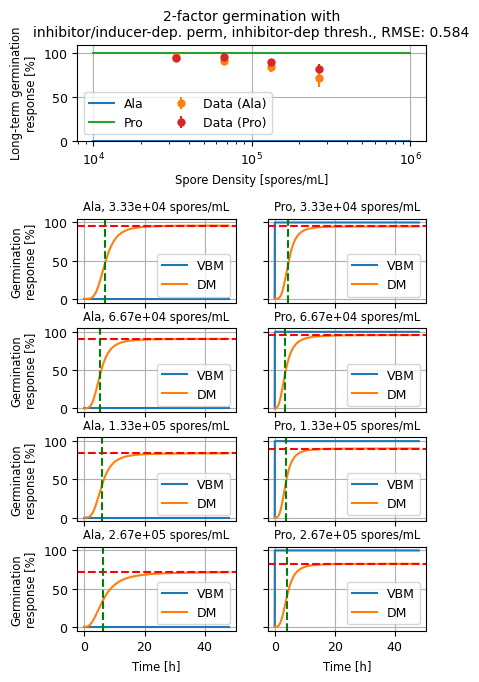

In [6]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_inducer_perm_inhibitor_thresh.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_inducer_perm_inhibitor_thresh", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.7. Inhibitor-dependent cell wall permeability and induction signal, inducer-dependent inhibition threshold (BCD)

The ODEs are as in 2.1.2., the induction signal is dynamically modulated by the inhibition concentration and the inhibition threshold in dynamically modulated by the inducing signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

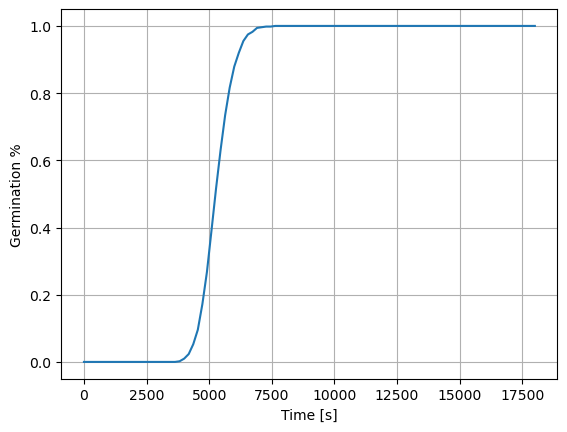

In [14]:
matplotlib.pyplot.close()

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_combined_inducer_thresh_inhibitor_perm_signal", times_eval, density_test, example_params)

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [17]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_thresh_inhibitor_perm_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: Inhibitor-dependent germination with inhibitor-dependent inhibitor/inducer permeability and inducer-dependent inhibition threshold
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
5.74 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=239.199697527
11.17 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=239.199697527
16.99 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=239.199697527
22.42 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 0.0000), fitness=239.199697527
28.23 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=239.199697527
34.00 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 0.0000), fitness=239.1996975

Dict{Any, Any} with 11 entries:
  :σ_ψ   => [0.571557]
  :n     => [1.27454, 2.96534]
  :μ_ψ   => [0.571557]
  :Pₛ    => [0.000513315]
  :σ_γ   => [1.26215e-5]
  :b_max => [0.999998]
  :k_C   => [239.703, 1.12595]
  :K_cI  => [0.0423186]
  :K_cC  => [0.0789555, 0.0176826]
  :μ_γ   => [6.7193e-5]
  :Pₛ_cs => [0.00636913, 0.00795535]

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_thresh_inhibitor_perm_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_thresh_inhibitor_perm_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

In [18]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_thresh_inhibitor_perm_signal", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm_signal.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 512
Model: 2-factor germination with inhibitor-dependent inhibitor/inducer permeability and inducer-dependent inhibition threshold
Running first optimisation stage


DomainError: DomainError with -8.168047440538023:
Normal: the condition σ >= zero(σ) is not satisfied.

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_thresh_inhibitor_perm_signal.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_thresh_inhibitor_perm_signal", params_test, times, sources, densities, p_maxs, taus, nus, errs)

#### 2.3.8. Inhibitor-dependent induction signal and threshold, inducer-dependent inhibition threshold (BCE)

This model has an analytical solution and only applies to 2-factor germination:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{{\omega_0}}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-k_1s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_{\omega_0}=\frac{s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-k_2c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}-\mu_{\omega_0}}{\sigma_{\omega_0}}.
\end{equation}
$$

#### 2.3.9. Inhibitor-dependent cell wall permeability and induction threshold, inducer-dependent inhibition threshold (BDE)

The ODEs are as in 2.1.2. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.3.10. Inhibitor-dependent cell wall permeability, induction signal and threshold (CDE)

The ODEs are as in 2.1.2. and both the inducer signal and threshold are dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

### 2.4. Quadruple-interaction models

#### 2.4.1. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction signal (ABCD)

The ODEs are as in 2.3.4. and the inhibition threshold is dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.4.2. Inducer-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction signal and threshold (ABCE)

The ODEs are as in 2.2.2. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.4.3. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction threshold (ABDE)

The ODEs are as in 2.2.3. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.4.4. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal and threshold (ACDE)

The ODEs are as in 2.3.4. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

#### 2.4.5. Inhibitor-dependent cell wall permeability, induction signal and threshold, inducer-dependent inhibition threshold (BCDE)

The ODEs are as in 2.1.2., while the inhibition threshold, the induction signal and threshold are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

### 2.5. Quintuple-interaction model: inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal and threshold, inducer-dependent inhibition threshold (ABCDE)

With all the interactions present, the ODEs from 2.3.4. govern, while the induction signal and both thresholds are dynamically modulated.